# Literature cost projections next to the learning engine

**Who this is for.** Readable without the rest of the repo open. Terms of art get a
short explanation at first use.

**The setting.** The paper's first result section asks what it would take for the
ATB 2050 nuclear cost projections to happen. The ATB (NREL's Annual Technology
Baseline) takes its nuclear costs from one source, the Idaho National Laboratory
meta-analysis by Abou-Jaoude and colleagues, which pairs each cost trajectory with a
deployment projection. Several other cost projections are in wide use: the Department
of Energy's Liftoff report, MIT's bottom-up AP1000 projection, INL's cost-reduction
pathways study, the EIA's capital cost study, EPRI's pooled FOAK/NOAK values, and the
IEA/NEA country estimates. This notebook puts them side by side with the ATB source and
with the paper's learning engine (the model that turns a deployment schedule into an
overnight-cost path; OCC, the build cost with no financing charges, in 2022 dollars per
kilowatt). Three questions, in order:

1. **What does each projection assume?** A comparison table of model form, learning
   rate (the cost decline per doubling of cumulative units), anchor attachment (which
   unit carries the starting cost), unit size, vendor structure, spillover, dollar year,
   durations, and whether the cost is paired with a deployment.
2. **What do they predict?** Every (cost, cumulative build) pair each source publishes,
   drawn on one axis — including all three Abou-Jaoude trajectories per technology at
   every milestone year — so relative levels, slopes and timing are visible.
3. **Where does each projection sit in the engine's parameter space?** For every
   series, the set of engine worlds (learning rate, spillover, foreign deployment,
   vendor count, experience base, combination rule, anchor cost) that reproduces the
   series inside its own significance band, under two readings of what a single
   design's unit count means for a national program.

Gates, quoting rules, and kill rules were fixed in `methods.md` before this notebook
was first executed. Tables are `c01` and up; figures `e01` and up. Run on the
**playground-env** kernel from `z-ethan/lit_comparison/`.


In [1]:
# Setup: paths, deflator, house style, reproducibility. The ported engine cells below read
# the mc/ folder through the sibling's names (NB_DIR, REPO_ROOT, EXPORTS), so those are
# aliased to mc/; everything THIS notebook writes goes to LIT_EXPORTS / LIT_FIGURES only.
import json
import sys
import time as _time
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

HERE = Path.cwd()
assert HERE.name == "lit_comparison", f"run from z-ethan/lit_comparison/, not {HERE}"
REPO = HERE.parents[1]
MC_DIR = HERE.parent / "mc"
DATA = HERE / "data"
LIT_EXPORTS = HERE / "exports"
LIT_FIGURES = HERE / "figures"
LIT_EXPORTS.mkdir(exist_ok=True)
LIT_FIGURES.mkdir(exist_ok=True)

# Aliases required by the ported cells (they never write anything).
NB_DIR = MC_DIR
REPO_ROOT = REPO
EXPORTS = MC_DIR / "exports"
ATB_OUT = EXPORTS / "atb"
assert (NB_DIR / "pris_loader.py").exists() and (EXPORTS / "mc_perdraw.npz").exists()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))
import pris_loader as pl  # noqa: E402  (used by the ported experience cell)

MASTER_SEED = 20260715

def rng_stream(name):
    """An independent, reproducible random generator tied to a label (house convention)."""
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

sys.path.insert(0, str(HERE.parent))
import plotstyle as ps
ps.apply()
INK, MUTED, FAINT = ps.INK, ps.MUTED, ps.FAINT
TECH_COLOR, TECH_LABEL = dict(ps.COL), dict(ps.TECH_LABEL)
# ATB scenarios are ordered, so they are monotone-lightness steps of each technology's
# hue (the sibling notebook's documented exception to the one-hue rule; same values).
SCEN_ORDER = ["conservative", "moderate", "advanced"]
SCEN_COLOR = {
    "large": {"conservative": "#86b6ef", "moderate": "#3987e5", "advanced": "#184f95"},
    "smr":   {"conservative": "#f2a284", "moderate": "#eb6834", "advanced": "#a33d15"},
}

# Dollar years: deflator.csv gives Deflator(t) relative to 2004; X_2022 = X_y * D(y)/D(2022).
DEFL = pd.read_csv(REPO / "inputs" / "financials" / "deflator.csv")
DEFL.columns = ["t", "Deflator"]
DEFL = DEFL.set_index("t")["Deflator"]

def to2022(x, dollar_year):
    """Convert a $ amount stated in `dollar_year` dollars to 2022 dollars."""
    return np.asarray(x, float) * float(DEFL.loc[int(dollar_year)]) / float(DEFL.loc[2022])

assert abs(to2022(8300, 2024) - 7749) < 5, to2022(8300, 2024)     # A5 hand check
VERDICT = []                       # (kind, name, result, detail) rows -> c99_verdict.csv
PORTED_SHA = {
    "atb_parameter_space cell 3": "e6fbf42ca49e139563351f3933d1331d0494ddee85f5bbe2569262893aeb7cb3",
    "atb_parameter_space cell 4": "a9f1a8e110c3b37fa7d524be21771ad73dfd0de2453a48078cd294b29d3585bc",
    "atb_parameter_space cell 5": "45ce5907fefa517791da3ef5bcbfbc47eb5da754536a978b8f5f3923ad4e3a17",
    "atb_parameter_space cell 6": "433a7fec2a84fbf3cb44ac5d7f211bf04dc20e913b02cb78204a6ce2b33ee991",
    "atb_parameter_space cell 20": "5a4850293a7de028eacc6721d05852e089bdaf5d05e7d3b1b07b11c61e49aebf"
}          # filled at build time
print(f"repo: {REPO}\nengine source: {MC_DIR/'atb_parameter_space.ipynb'}")
print(f"2024$ -> 2022$: x{float(DEFL.loc[2024])/float(DEFL.loc[2022]):.4f};  2019$ -> 2022$: x{float(DEFL.loc[2019])/float(DEFL.loc[2022]):.4f}")


repo: C:\Users\ethan\code\research\ReEDS-nuclear-learning
engine source: C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc\atb_parameter_space.ipynb
2024$ -> 2022$: x0.9335;  2019$ -> 2022$: x1.1443


## Part 0 — the engine, ported verbatim, and its parity gate

The next cells are copied at build time from `mc/atb_parameter_space.ipynb` (which
itself ports them from `mc_cost_trajectories.ipynb`): the model-frame constants, the
historical and international experience stocks, the OCC engine, and the sibling's
QA-0 parity check against the production Monte Carlo draws (`mc_perdraw.npz`). That
check is gate **G0**: if it passes, everything downstream runs on *the* engine.

One generalisation follows (own code): the sibling's closed-form 2050 evaluator
depends on the year only through the foreign experience stock, so `shape_at(...,
year)` evaluates the same algebra at any year. Gate **G0b** checks it against the full
engine at 2035/2040/2045/2050.


In [2]:
# ---- PORTED VERBATIM at build time from mc/atb_parameter_space.ipynb cell 3 (content-asserted: 'N_BOAK_UNITS'). Do not edit here; edit the sibling. ----
# Model-frame constants - verbatim from mc_cost_trajectories.ipynb S1 (analysis switches and
# draw-count settings dropped: nothing is drawn here).
YEARS = np.arange(2024, 2051)              # annual grid, 2024-2050
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030          # the anchor year: costs are pinned to known 2030 estimates (S5)
N_BOAK_UNITS = 2.0     # per-vendor experience at the anchor ("BOAK = 2OAK")
OMEGA = 1.0 / 3.0      # cross-firm learning fraction (Irwin & Klenow 1994)

# Symmetric around 0 since 2026-08-06 (companion S1): the old {-2, -1, 0, 1} grid put half
# its mass on complements, which gate the international channel to ~zero.
CES_RHO_GRID = np.array([-1.0, 0.0, 1.0])

X_SPILL_MAX = 0.30   # cross-tech spillover cap (the MC draws U(0, X_SPILL_MAX) per direction);
                     # this notebook pins x_ls = x_sl = 0.15 - inert here, since no fit ever
                     # passes an other-tech program (n_oth) to the engine

# Per-technology assumptions: unit size, learning-rate range, 2030 anchor-cost range
# (2022 USD per kW; Abou-Jaoude Table A-1 / NREL ATB 2024)
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0  # foreign new builds are treated as 1-GW large reactors

U_GRID = np.linspace(0.0, 1.0, 21)   # grid for the international-deployment position u (S3)

print(f"model frame: {YEARS[0]}-{YEARS[-1]} annual (T={T}), anchor {ANCHOR}, "
      f"BOAK=2OAK per vendor, omega={OMEGA:.3f}")

model frame: 2024-2050 annual (T=27), anchor 2030, BOAK=2OAK per vendor, omega=0.333


In [3]:
# ---- PORTED VERBATIM at build time from mc/atb_parameter_space.ipynb cell 4 (content-asserted: 'US_GW_2024 = 97.0'). Do not edit here; edit the sibling. ----
# Historical + international experience - verbatim from mc_cost_trajectories.ipynb S3.
# Non-US regional milestones (GW): 2024, 2030 Low/High, 2040 Low/High, 2050 Low/High
# (IAEA RDS-1 2025 projections + WNA/CNA).
REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
# Kim & Verdolini (2023)-derived knowledge-spillover ceilings (US as recipient)
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

US_GW_2024 = 97.0
PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues   # the data file must reproduce the IAEA's own totals

FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2030   # pipeline's real visibility horizon; structurally zero after 2030 (mc S3)
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}

# Under-construction units are excluded: 5 carry PLANNED grid dates (not completed experience)
_ever = PRIS_UNITS[(PRIS_UNITS["status"] != "under construction")
                   & PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}

US_LICENSE_LIFE = 80.0   # yr - US subsequent-license-renewal trend; ~0 US retirements before 2050
ONE_FACTOR_DELTA = 0.0   # bounded regional noise on u (0 = one global u; variance-conservative)

def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through PIPE_END = 2030 (real units; structurally
    zero after 2030, so it only shapes the pre-anchor record - see mc_cost_trajectories S3)."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 65.0 + 5.0*u)   # IAEA-calibrated lives, 65+5u (mc S3; 2026-08-05)
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

def post_anchor_cum(flow):
    """Cumulative builds counted from the 2030 anchor, END-of-year basis. The one-year
    completion lag - a year's builds price only LATER years - is applied at the pricing
    boundary (lag1 in the engine cell), companion-identical."""
    x = flow.copy()
    x[YEARS <= ANCHOR] = 0.0
    return np.cumsum(x)

# Foreign stocks on the u grid (mc S3): unsplit, 1-GW basis - the engine's cross-firm
# channel does not distinguish designs (mc S5 Step 5). The IAEA SMR-share split of the
# foreign fleet lives in the main notebook's S14 own-routing sensitivity, not in any engine.
# REGION_STOCK[r][gi] = cumulative post-anchor units at u = U_GRID[gi]
REGION_STOCK = {}
for r in REGIONS:
    m_a = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        m_a[gi] = post_anchor_cum(gross_additions_gw(r, u)) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m_a

US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)

# The six paper schedules, read from the exported single source of truth - needed ONLY by QA-0
# (to reproduce the companion's trajectories); the analysis itself uses the Abou-Jaoude
# deployments built in A3.
OFFSET_GW = 3.0
_sched = pd.read_csv(REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv",
                     comment="#").set_index("year")
assert list(_sched.index) == list(YEARS)
SCEN_TOKENS = list(_sched.columns)
USN_NEW = {}     # USN_NEW[tech][token] -> (T,) cumulative post-anchor new units
for tech in TECH:
    USN_NEW[tech] = {}
    for tok in SCEN_TOKENS:
        cap = _sched[tok].to_numpy(float) - OFFSET_GW
        dnet = np.diff(cap, prepend=cap[0])
        USN_NEW[tech][tok] = post_anchor_cum(np.clip(dnet + US_RET, 0.0, None)) / TECH[tech]["unit_gw"]

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction; "
      f"schedules for QA-0: {SCEN_TOKENS}")

PRIS fleet loaded: 417 operational, 62 under construction; schedules for QA-0: ['eia_aeo_high', 'abou_jaoude', 'iaea_high', 'mckinsey', 'cop28', 'eo2025']


In [4]:
# ---- PORTED VERBATIM at build time from mc/atb_parameter_space.ipynb cell 5 (content-asserted: 'def occ_paths_ces'). Do not edit here; edit the sibling. ----
# The OCC engine - verbatim from mc_cost_trajectories.ipynb S5 (draw_world not ported: this
# notebook evaluates designed worlds, it draws none), plus the two additions described above.
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)   # theta-weighted historical foreign stock
OTHER_TECH = {"large": "smr", "smr": "large"}
X_IN_COL = {"large": "x_sl", "smr": "x_ls"}     # incoming cross-tech fraction, per receiving tech

def lag1(a):
    """One-year completion lag along the time axis: the stock ENTERING year t is the builds
    completed through t-1. Cumulative arrays stay end-of-year for accounting; the lag is
    applied here, at the pricing boundary - without it the first post-anchor cohort would
    price on its own not-yet-built units (below BOAK). Companion-identical (mc S5)."""
    a = np.asarray(a, float)
    out = np.zeros_like(a)
    out[..., 1:] = a[..., :-1]
    return out

def experience_channels(world, tech, n_us, n_oth=None):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).

    n_us:  the schedule's cumulative post-anchor US builds of THIS technology, shape (T,).
    n_oth: the OTHER technology's cumulative post-anchor US builds, (T,) or None. The drawn
           incoming cross-tech fraction x scales it into the cross-firm channel; this
           notebook's single-technology fits never pass it, so x stays inert here.

    International experience enters the CROSS-FIRM channel at weight s*theta, unsplit
    across technologies (mc S5 Step 5): the Kim & Verdolini flows are normalized to the
    domestic INTER-FIRM citation baseline (their eq. (5); self-citations excluded), so
    theta prices the extra national border ON TOP OF the firm wall - omega once for the
    firm wall, theta once for the border.
    """
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:   # optional bounded regional noise on u (off by default)
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_kv = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_kv += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    S_kv = lag1(S_kv)                                    # stock entering year t (built thru t-1)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    # US historical fleet counts toward LARGE only (D8'): the SMR learning-rate range is
    # empirically derived and already embeds any benefit from prior LWR builds, so crediting
    # the ~140-unit US stock to the SMR base would double-count it. The theta-weighted
    # FOREIGN stock (historical and projected) is not-own-design experience for both
    # technologies alike and enters the cross-firm channel unsplit.
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m                     # per-vendor domestic base (D8/D8')
    own = own0 + N_us/m                                      # own-design units, learn at LR
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + S_kv)                          # others + international, at OMEGA*LR
    if n_oth is not None:                                    # cross-tech: the other technology's
        x = world[X_IN_COL[tech]].values[:, None]            # incoming cross-tech fraction
        oth = oth + x*lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))  # US program (Step 5')
    return own, oth

def occ_paths(world, tech, n_us, n_oth=None):
    """Reference engine (D9, sigma = 1). Kept untouched as the regression benchmark for the
    CES engine below - QA-1 asserts occ_paths_ces(rho -> 0) reproduces it exactly. n_oth
    passes through to experience_channels."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth)
    lr = world[f"lr_{tech}"].values[:, None]
    mult = ((own/own[:, [yi(ANCHOR)]])**np.log2(1.0 - lr)
            * (oth/oth[:, [yi(ANCHOR)]])**np.log2(1.0 - OMEGA*lr))
    return world[f"boak_{tech}"].values[:, None] * mult

CES_EPS = 1e-8   # |ces_rho| below this takes the closed-form geometric-mean branch

def occ_paths_ces(world, tech, n_us, n_oth=None, ces_rho=None):
    """Production engine (D11/D12): CES power-mean aggregation of the two channels,
    E = (w O^rho + (1-w) A^rho)^(1/rho), OCC = BOAK (E(t)/E(2030))^(-b), with (w, b)
    derived per-draw from (LR, omega) so the rho -> 0 member reproduces occ_paths EXACTLY.
    n_oth passes through to experience_channels."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)     # channel exponents, both < 0
    b, w = -(b1 + b2), b1/(b1 + b2)                         # b > 0, w in (0,1)  (D12)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def eq12_gen(N, LR, m):
    """Abou-Jaoude eq. (12) generalized to m vendors (companion QA3): the closed form the
    engine collapses to at s = 0, tiny base, rho = 0."""
    return (1-LR)**np.log2(N/m) * (1-OMEGA*LR)**np.log2((m-1)*N/m)

def make_worlds(lr, boak, u, s, m, conv, rho):
    """Designed-world frame for the engine: every input pinned, no draws (adapted from
    smr100_case_export.ipynb's make_world; the lr/boak dials are direct values here, applied
    to BOTH techs' columns - each fit evaluates a single technology, so the twin columns are
    just along for the engine's column layout)."""
    arrs = np.broadcast_arrays(*[np.asarray(a, float) for a in (lr, boak, u, s, m, conv, rho)])
    w = pd.DataFrame(index=range(arrs[0].size))
    for tech in TECH:
        w[f"lr_{tech}"] = arrs[0].ravel()
        w[f"boak_{tech}"] = arrs[1].ravel()
    for k, a in zip(("u", "s", "n_vendors", "conv_full", "ces_rho"),
                    (arrs[2], arrs[3], arrs[4], arrs[5], arrs[6])):
        w[k] = a.ravel()
    w["x_ls"] = 0.15   # cross-tech spillover fractions, pinned at the drawn range's midpoint -
    w["x_sl"] = 0.15   # inert here (no other-tech program is passed; companion S5 Step 5')
    return w

print(f"engine ready: H_ALL_W = {H_ALL_W:.1f} theta-weighted historical foreign units; "
      f"US historical fleet = {HIST_UNITS['US']} units (large only, full-stock convention)")

engine ready: H_ALL_W = 83.5 theta-weighted historical foreign units; US historical fleet = 135 units (large only, full-stock convention)


In [5]:
# ---- PORTED VERBATIM at build time from mc/atb_parameter_space.ipynb cell 6 (content-asserted: 'QA-0'). Do not edit here; edit the sibling. ----
# QA-0 - engine-port parity: evaluate the ported engine on the companion's OWN drawn worlds
# and require the stored OCC trajectories back, for all six schedules x both technologies.
# This is the smr100_case_export QA-0 pattern, inverted: instead of re-drawing the worlds we
# load them, so the check isolates the ENGINE port (experience stocks, CES aggregation,
# anchor convention) from the sampler. Tolerance is cross-kernel floating-point rounding only.
_npz_path = EXPORTS / "mc_perdraw.npz"
assert _npz_path.exists(), ("exports/mc_perdraw.npz not found - run mc_cost_trajectories.ipynb "
                            "(S10b) first; QA-0 is the gate that this notebook runs the real engine")
Z0 = np.load(_npz_path, allow_pickle=False)
_wcols = [str(c) for c in Z0["world_columns"]]
assert list(Z0["years"]) == list(YEARS)
for tok in SCEN_TOKENS:
    _w = pd.DataFrame(Z0[f"worlds_{tok}"], columns=_wcols)
    for tech in TECH:
        _occ = occ_paths_ces(_w, tech, USN_NEW[tech][tok])
        assert np.allclose(_occ, Z0[f"occ_{tok}_{tech}"], rtol=1e-9, atol=0.0), (tok, tech)
_n0 = Z0[f"worlds_{SCEN_TOKENS[0]}"].shape[0]
print(f"QA-0 PASSED: ported engine reproduces the companion's OCC trajectories on its own "
      f"{_n0:,} drawn worlds, all {len(SCEN_TOKENS)} schedules x both techs (rtol 1e-9)")
del Z0, _w, _occ

QA-0 PASSED: ported engine reproduces the companion's OCC trajectories on its own 10,000 drawn worlds, all 6 schedules x both techs (rtol 1e-9)


In [6]:
VERDICT.append(("gate", "G0", "PASS", "ported engine reproduces mc_perdraw.npz (6 schedules x 2 techs, rtol 1e-9)"))

In [7]:
# ---- PORTED VERBATIM at build time from mc/atb_parameter_space.ipynb cell 20 (content-asserted: 'def shape_2050'). Do not edit here; edit the sibling. ----
# The closed-form 2050 evaluator (single-year restriction of occ_paths_ces), and QA-5.
I2050 = yi(2050)

def skv_2050(u):
    """Theta-weighted foreign stock ENTERING the 2050 price, per world: builds through 2049
    (the engine's one-year completion lag), post-anchor basis (years <= 2030 zeroed);
    unsplit across technologies (the cross-firm channel does not distinguish designs)."""
    gi = np.clip(np.rint(np.asarray(u, float) * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    return sum(THETA_KV[r] * REGION_STOCK[r][gi, I2050 - 1] for r in REGIONS)

def shape_2050(tech, lr, s, u, m, conv, rho, n2050):
    """OCC(2050)/BOAK for a post-anchor stock of n2050 units ENTERING the 2050 price (builds
    completed through 2049, per the engine's one-year lag) - vectorized over worlds.
    Identical algebra to occ_paths_ces restricted to the 2050 and anchor columns: the
    theta*s-weighted foreign stock (and, under full-stock, the all-LWR historical fleet)
    sits in the cross-firm channel, unsplit across technologies (companion S5 Step 5).
    No other-tech US program appears here (Part 2 prices a single technology's deployment;
    n_oth stays None throughout), so the drawn cross-tech x never enters."""
    lr, s, m, conv, rho, n2050 = np.broadcast_arrays(
        *[np.asarray(a, float) for a in (lr, s, m, conv, rho, n2050)])
    skv = np.broadcast_to(skv_2050(u), lr.shape)
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    H_kv = conv*H_ALL_W                                  # foreign historical: both techs alike
    own0 = N_BOAK_UNITS + conv*hist_us/m
    ownA = own0
    own50 = own0 + n2050/m
    othA = (m-1.0)*own0 + s*H_kv                         # S_KV at the anchor is 0
    oth50 = (m-1.0)*own0 + n2050*(m-1.0)/m + s*(H_kv + skv)
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    geo = np.abs(rho) < CES_EPS
    rho_safe = np.where(geo, 1.0, rho)
    def _lnE(o, a):
        lnO, lnA = np.log(o), np.log(a)
        return np.where(geo, w*lnO + (1.0-w)*lnA,
                        lnO + np.log1p((1.0-w)*np.expm1(rho_safe*(lnA - lnO)))/rho_safe)
    return np.exp(-b*(_lnE(own50, oth50) - _lnE(ownA, othA)))

# --- QA-5a: the closed form equals the full engine's 2050 column (random worlds, both techs)
_rng5 = rng_stream("atb/qa5")
_n5 = 400
_qa = {k: _rng5.uniform(*b, _n5) for k, b in
       [("lr", (0.005, 0.30)), ("s", (0, 1)), ("u", (0, 1))]}
_qa["m"] = _rng5.integers(4, 9, _n5).astype(float)
_qa["conv"] = _rng5.integers(0, 2, _n5).astype(float)
_qa["rho"] = _rng5.choice(CES_RHO_GRID, _n5)
for tech in TECH:
    n2050 = _rng5.uniform(0.0, 3000.0, _n5)
    for i in range(0, _n5, 50):      # engine takes one n_us per call -> spot-check 8 worlds/tech
        sl = slice(i, i + 1)
        ramp = np.where(YEARS <= ANCHOR, 0.0, (YEARS - ANCHOR)/(2050.0 - ANCHOR)) * n2050[i]
        w1 = make_worlds(_qa["lr"][sl], 1.0, _qa["u"][sl], _qa["s"][sl],
                         _qa["m"][sl], _qa["conv"][sl], _qa["rho"][sl])
        full = occ_paths_ces(w1, tech, ramp)[0, I2050]
        closed = shape_2050(tech, _qa["lr"][sl], _qa["s"][sl], _qa["u"][sl], _qa["m"][sl],
                            _qa["conv"][sl], _qa["rho"][sl],
                            np.array([ramp[I2050 - 1]]))[0]     # stock ENTERING 2050
        assert abs(full - closed) < 1e-10, (tech, i, full, closed)
print("QA-5a PASSED: closed-form 2050 evaluator == full engine's 2050 column "
      "(8 random worlds x both techs x linear-ramp schedules)")

# --- QA-5b: path invariance - different build timings, same cumulative 2050 stock, same OCC(2050)
_w5 = make_worlds([0.11], 1.0, [0.6], [0.5], [5.0], [0.0], [-1.0])
# Equal cumulative stock ENTERING 2050 (= builds through 2049, the engine's lag) under
# three different timings; the 2050 price must agree.
_lin = np.minimum(np.where(YEARS <= ANCHOR, 0.0, (YEARS - ANCHOR)/19.0), 1.0) * 300.0
_late = np.minimum(np.where(YEARS <= 2044, 0.0, (YEARS - 2044)/5.0), 1.0) * 300.0   # builds 2045-2049
_early = np.minimum(np.where(YEARS <= ANCHOR, 0.0, (YEARS - ANCHOR)/5.0), 1.0) * 300.0
_v = [occ_paths_ces(_w5, "smr", p)[0, I2050] for p in (_lin, _late, _early)]
assert np.ptp(_v) < 1e-12, _v
print(f"QA-5b PASSED: OCC(2050) is path-invariant at fixed cumulative completed build "
      f"(linear / back-loaded / front-loaded schedules agree to {np.ptp(_v):.1e})")

# --- QA-5c: monotonicity in the cumulative build (validates bisection)
_Ns = np.logspace(-2, 4.5, 300)
for tech in TECH:
    sh = shape_2050(tech, 0.08, 0.5, 0.5, 6.0, 0.0, 0.0, _Ns)
    assert (np.diff(sh) < 0).all(), tech
    sh_full = shape_2050(tech, 0.08, 0.5, 0.5, 6.0, 1.0, 0.0, _Ns)
    assert (np.diff(sh_full) < 0).all(), tech
print("QA-5c PASSED: OCC(2050) strictly decreasing in cumulative build (both techs, both bases)")

QA-5a PASSED: closed-form 2050 evaluator == full engine's 2050 column (8 random worlds x both techs x linear-ramp schedules)
QA-5b PASSED: OCC(2050) is path-invariant at fixed cumulative completed build (linear / back-loaded / front-loaded schedules agree to 0.0e+00)
QA-5c PASSED: OCC(2050) strictly decreasing in cumulative build (both techs, both bases)


In [8]:
# shape_at: the closed form at ANY year (own code; algebra identical to shape_2050, the
# foreign stock indexed at the requested year). n = post-anchor US units ENTERING the
# price of `year` (completed through year-1, the engine's one-year lag).
def skv_at(u, year):
    gi = np.clip(np.rint(np.asarray(u, float) * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    return sum(THETA_KV[r] * REGION_STOCK[r][gi, yi(year) - 1] for r in REGIONS)

def shape_at(tech, lr, s, u, m, conv, rho, n, year):
    """OCC(year)/BOAK for a post-anchor stock of n units entering the price of `year`."""
    lr, s, m, conv, rho, n = np.broadcast_arrays(
        *[np.asarray(a, float) for a in (lr, s, m, conv, rho, n)])
    skv = np.broadcast_to(skv_at(u, year), lr.shape)
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    H_kv = conv*H_ALL_W
    own0 = N_BOAK_UNITS + conv*hist_us/m
    ownA = own0
    ownT = own0 + n/m
    othA = (m-1.0)*own0 + s*H_kv
    othT = (m-1.0)*own0 + n*(m-1.0)/m + s*(H_kv + skv)
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    geo = np.abs(rho) < CES_EPS
    rho_safe = np.where(geo, 1.0, rho)
    def _lnE(o, a):
        lnO, lnA = np.log(o), np.log(a)
        return np.where(geo, w*lnO + (1.0-w)*lnA,
                        lnO + np.log1p((1.0-w)*np.expm1(rho_safe*(lnA - lnO)))/rho_safe)
    return np.exp(-b*(_lnE(ownT, othT) - _lnE(ownA, othA)))

# G0b: shape_at == the full engine's column at 2035/2040/2045/2050 on random worlds and
# random (non-decreasing, zero through 2030) cumulative paths; and == shape_2050 at 2050.
_rng = rng_stream("lit/g0b")
_n = 400
_g = {"lr": _rng.uniform(0.005, 0.30, _n), "s": _rng.uniform(0, 1, _n), "u": _rng.uniform(0, 1, _n),
      "m": _rng.integers(4, 9, _n).astype(float), "conv": _rng.integers(0, 2, _n).astype(float),
      "rho": _rng.choice(CES_RHO_GRID, _n)}
_worst = 0.0
_t0 = _time.time()
for tech in TECH:
    for i in range(_n):
        flows = _rng.uniform(0.0, 1.0, T)
        flows[YEARS <= ANCHOR] = 0.0
        path = np.cumsum(flows)
        path *= _rng.uniform(0.0, 3000.0) / TECH[tech]["unit_gw"] / path[-1]
        w1 = make_worlds(_g["lr"][i:i+1], 1.0, _g["u"][i:i+1], _g["s"][i:i+1],
                         _g["m"][i:i+1], _g["conv"][i:i+1], _g["rho"][i:i+1])
        full = occ_paths_ces(w1, tech, path)[0]
        for y in (2035, 2040, 2045, 2050):
            closed = shape_at(tech, _g["lr"][i:i+1], _g["s"][i:i+1], _g["u"][i:i+1], _g["m"][i:i+1],
                              _g["conv"][i:i+1], _g["rho"][i:i+1], np.array([path[yi(y) - 1]]), y)[0]
            _worst = max(_worst, abs(full[yi(y)] - closed))
assert _worst < 1e-9, _worst
_v = shape_2050("smr", _g["lr"], _g["s"], _g["u"], _g["m"], _g["conv"], _g["rho"], _g["lr"]*1000)
_w = shape_at("smr", _g["lr"], _g["s"], _g["u"], _g["m"], _g["conv"], _g["rho"], _g["lr"]*1000, 2050)
assert np.array_equal(_v, _w)
print(f"G0b PASSED: shape_at == full engine at 2035/40/45/50 on {2*_n} random worlds x paths "
      f"(worst |diff| {_worst:.1e}); shape_at(2050) == shape_2050 exactly  [{_time.time()-_t0:.0f}s]")
VERDICT.append(("gate", "G0b", "PASS", f"closed form at any year == full engine, worst diff {_worst:.1e}"))

# The sibling's grids (values copied from its cells 12 and 21; sizes asserted against its manifest).
LR_GRID = np.round(np.arange(0.005, 0.3001, 0.005), 3)
S21 = np.round(np.linspace(0.0, 1.0, 21), 3)
U21 = U_GRID.copy()
M_GRID = np.array([4.0, 5.0, 6.0, 7.0, 8.0])
CONV_GRID = np.array([0.0, 1.0])
DISC_COMBOS = [(rho, conv, m) for rho in CES_RHO_GRID for conv in CONV_GRID for m in M_GRID]
U3 = np.array([0.0, 0.5, 1.0])
_m2 = np.meshgrid(LR_GRID, S21, U3, indexing="ij")
LR2, S2, U2 = (a.ravel() for a in _m2)
NP2 = LR2.size
G = {"lr": np.tile(LR2, len(DISC_COMBOS)), "s": np.tile(S2, len(DISC_COMBOS)),
     "u": np.tile(U2, len(DISC_COMBOS)),
     "rho": np.repeat([c[0] for c in DISC_COMBOS], NP2),
     "conv": np.repeat([c[1] for c in DISC_COMBOS], NP2),
     "m": np.repeat([c[2] for c in DISC_COMBOS], NP2)}
NG = G["lr"].size
G_SHAPE = (len(CES_RHO_GRID), len(CONV_GRID), len(M_GRID), len(LR_GRID), len(S21), len(U3))
_meta = json.loads((ATB_OUT / "atb_metadata.json").read_text(encoding="utf-8"))
assert _meta["grid"]["worlds_per_fit"] == len(DISC_COMBOS) * len(LR_GRID) * len(S21) * len(U21) == 793_800
SUPPORT = {t: (G["lr"] >= TECH[t]["lr_lo"]) & (G["lr"] <= TECH[t]["lr_hi"]) for t in TECH}
print(f"Part-2 scoring grid: {NG:,} worlds (LR {len(LR_GRID)} x s {len(S21)} x u {len(U3)} x m {len(M_GRID)} "
      f"x base {len(CONV_GRID)} x rho {len(CES_RHO_GRID)}); support-restricted: "
      + ", ".join(f"{t} {int(SUPPORT[t].sum()):,}" for t in TECH))


G0b PASSED: shape_at == full engine at 2035/40/45/50 on 800 random worlds x paths (worst |diff| 0.0e+00); shape_at(2050) == shape_2050 exactly  [1s]
Part-2 scoring grid: 113,400 worlds (LR 60 x s 21 x u 3 x m 5 x base 2 x rho 3); support-restricted: large 35,910, smr 51,030


## Part A — the projections and what each assumes

**The data layer.** Hand-transcribed points live in `data/lit_sources.csv` (each row
quotes its page or table and carries a URL). Two series exist only as figures and were
digitized by `_digitize_figures.py`: INL's Figure 10 is vector graphics, so its 26 bar
totals are exact up to the axis calibration; MIT's Figure 2 is a raster image, so its 21
bar tops are read against the chart's own gridlines (read error about $190/kW). Gate
**G1** compares the digitized values with the values the reports state in their text.
The Abou-Jaoude/ATB rows are generated from the ATB files the fork ships and from the
source's deployment table, never transcribed by hand. The INL 2023 literature review
gives a parametric curve, generated here from its published quartiles.

**Three conventions applied to every point** (assumption register in `methods.md`):

- *Band (A1).* Each point carries the source's stated range where it gives one, the
  ATB's ±$125/kW rounding half-step for Abou-Jaoude milestones, and ±10% where the
  source gives a bare number. Digitized points add their read error.
- *Units (A2, A6).* The engine anchors each vendor's cost at its second unit, so a
  source's cumulative unit N is post-anchor unit N−2. First- and second-of-a-kind
  points are plotted hollow and never scored.
- *Dollars (A5).* Everything is converted to 2022 dollars with the fork's deflator table.


In [9]:
# Load and assemble every projection into one table of points (c02), in 2022 dollars with bands.
ATB_T = pd.read_csv(ATB_OUT / "atb_targets.csv", header=[0, 1], index_col=0)
AJ_CSV = HERE.parent / "abou-jaoude nuclear deployment projections.csv"
assert f"{zlib.crc32(AJ_CSV.read_bytes()):08x}" == "5afa8dfd", "AJ deployment CSV changed"
_aj = pd.read_csv(AJ_CSV).set_index("year")
AJ_YEARS = _aj.index.values.astype(float)
MILESTONES = [2030, 2035, 2040, 2045, 2050]
AJ_GW = {s: _aj[s].values.astype(float) for s in SCEN_ORDER}
AJ_GW_POST = {s: AJ_GW[s][-1] - AJ_GW[s][0] for s in SCEN_ORDER}
AJ_GW_ENT50 = {s: float(np.interp(2049.0, AJ_YEARS, AJ_GW[s]) - AJ_GW[s][0]) for s in SCEN_ORDER}

def aj_units_entering(scen, tech, year):
    """Post-anchor AJ units ENTERING the price of `year` (builds through year-1; flows at or
    before 2030 zeroed - the sibling's N_AJ convention)."""
    gw = float(np.interp(year - 1, AJ_YEARS, AJ_GW[scen]) - AJ_GW[scen][0])
    return max(gw, 0.0) / TECH[tech]["unit_gw"]

rows = []
# --- Abou-Jaoude / ATB 2024: 2 techs x 3 scenarios x 5 milestones, paired with his deployment path
for tech in TECH:
    for scen in SCEN_ORDER:
        for y in MILESTONES:
            occ = float(ATB_T[(tech, scen)].loc[y])
            gw_post = float(AJ_GW[scen][list(AJ_YEARS).index(y)] - AJ_GW[scen][0])
            rows.append(dict(source_id="atb_aj", series_id=f"aj_{scen}", tech=tech, point_id=str(y),
                             label=f"ATB {scen} {y}", n_units=np.nan, n_post=aj_units_entering(scen, tech, y),
                             cum_gw=gw_post, year=y, occ=occ, occ_lo=occ - 125.0, occ_hi=occ + 125.0,
                             dollar_year=2022, basis="BOAK" if y == 2030 else "milestone", provenance="table",
                             band_rule="atb125", scored=1, read_set="R1", n_lo=np.nan, n_hi=np.nan,
                             note="ATB 2024 file value at the paired Abou-Jaoude deployment"))
# --- hand-transcribed points
src = pd.read_csv(DATA / "lit_sources.csv")
for r in src.itertuples(index=False):
    n = r.n_units
    npost = (n - N_BOAK_UNITS) if pd.notna(n) else np.nan
    scored = int(r.scored) and pd.notna(n) and (n > N_BOAK_UNITS) and (r.basis != "FOAK")   # A2: FOAK never scored
    rows.append(dict(source_id=r.source_id, series_id=r.series_id, tech=r.tech, point_id=r.point_id,
                     label=r.label, n_units=n, n_post=npost, cum_gw=r.cum_gw, year=r.year, occ=r.occ,
                     occ_lo=(r.occ_lo if pd.notna(r.occ_lo) else 0.9*r.occ),
                     occ_hi=(r.occ_hi if pd.notna(r.occ_hi) else 1.1*r.occ),
                     dollar_year=r.dollar_year, basis=r.basis, provenance=r.provenance,
                     band_rule=r.band_rule, scored=int(scored), read_set="R1,R2",
                     n_lo=r.n_units_lo, n_hi=r.n_units_hi, note=r.note))
# --- MIT ANP-201 Fig 2 (digitized raster); stated ranges where the text gives them (A1)
mit = pd.read_csv(DATA / "mit_anp201_fig2_digitized.csv")
MIT_RANGE = {("mit_ap1000_23gw", 2): (8300.0, 10375.0), ("mit_ap1000_23gw", 7): (4625.0, 4750.0)}
for r in mit.itertuples(index=False):
    lo, hi = MIT_RANGE.get((r.series_id, int(r.offering)), (0.9*r.occ, 1.1*r.occ))
    tech = "large" if "ap1000" in r.series_id else "smr"
    rows.append(dict(source_id="mit_anp201", series_id=r.series_id, tech=tech, point_id=f"o{r.offering}",
                     label=f"MIT {r.label}", n_units=r.n_units, n_post=r.n_units - N_BOAK_UNITS,
                     cum_gw=r.cum_gw, year=r.year, occ=r.occ, occ_lo=lo - r.read_err, occ_hi=hi + r.read_err,
                     dollar_year=2024, basis=("FOAK" if r.offering == 1 else "NOAK" if r.offering == 7 else "NEXT"),
                     provenance="digitized-raster",
                     band_rule=("stated+read" if (r.series_id, int(r.offering)) in MIT_RANGE else "pct10+read"),
                     scored=int(r.n_units > N_BOAK_UNITS), read_set="R1,R2", n_lo=np.nan, n_hi=np.nan,
                     note=f"{r.design}; year finished {r.year}; A6 unit mapping"))
# --- INL cost-pathways Fig 10 (digitized vector, exact): Scenario 1, plants 1-13
inl = pd.read_csv(DATA / "inl_pathways_fig10_digitized.csv")
for r in inl.itertuples(index=False):
    rows.append(dict(source_id="inl_pathways", series_id=r.series_id, tech="smr", point_id=f"plant{r.plant}",
                     label=f"INL {r.design} plant {r.plant}", n_units=r.n_units, n_post=r.n_units - N_BOAK_UNITS,
                     cum_gw=r.cum_gw, year=np.nan, occ=r.occ, occ_lo=0.9*r.occ - r.read_err,
                     occ_hi=1.1*r.occ + r.read_err, dollar_year=2022,
                     basis=("FOAK" if r.plant == 1 else "order-book"), provenance="digitized-vector",
                     band_rule="pct10+read", scored=int(r.n_units > N_BOAK_UNITS and r.plant > 1), read_set="R1,R2",
                     n_lo=np.nan, n_hi=np.nan, note=f"{r.design}; Scenario 1 (realistic, no ITC); A4 plant = units"))
# --- INL 2023 literature review: parametric Wright curve from its published quartiles (2019$)
REV = {"low": (4000.0, 1.3), "central": (6000.0, 1.6), "high": (7000.0, 2.1)}     # (BOAK, FOAK premium)
REV_LR = 0.10                                   # its worked example applies the mean 10% at both ends
REV_N = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64]
for tech in TECH:
    for N in REV_N:
        c = {k: b*p*(1.0 - REV_LR)**np.log2(N) for k, (b, p) in REV.items()}
        rows.append(dict(source_id="inl_litreview", series_id="inl_review", tech=tech, point_id=f"N{N}",
                         label=f"INL 2023 review N={N}", n_units=N, n_post=N - N_BOAK_UNITS,
                         cum_gw=N*TECH[tech]["unit_gw"], year=np.nan, occ=c["central"], occ_lo=c["low"],
                         occ_hi=c["high"], dollar_year=2019, basis=("FOAK" if N == 1 else "parametric"),
                         provenance="derived", band_rule="quartile", scored=int(N > N_BOAK_UNITS),
                         read_set="R1,R2", n_lo=np.nan, n_hi=np.nan,
                         note="Cost_N = BOAK x premium x (1-LR)^log2 N; low/central/high = its quartiles and premiums, LR 10%"))
pts = pd.DataFrame(rows)
for col in ("occ", "occ_lo", "occ_hi"):
    pts[col + "_2022"] = [float(to2022(v, y)) for v, y in zip(pts[col], pts["dollar_year"])]
pts["paired"] = pts["cum_gw"].notna()
pts["dated"] = pts["year"].notna()
pts["year_mode"] = np.where(pts["dated"], "dated", "2050 (2030 bracket)")
pts = pts.sort_values(["tech", "source_id", "series_id", "cum_gw"], kind="stable").reset_index(drop=True)
pts.to_csv(LIT_EXPORTS / "c02_points_2022usd.csv", index=False)
n_sc = int(pts["scored"].sum())
print(f"c02: {len(pts)} points from {pts['source_id'].nunique()} sources, {pts['series_id'].nunique()} series; "
      f"{int(pts['paired'].sum())} paired with a deployment, {n_sc} scored -> exports/c02_points_2022usd.csv")
_show = pts[pts.paired][["series_id", "tech", "label", "n_units", "n_post", "cum_gw", "year", "occ", "dollar_year",
                         "occ_2022", "occ_lo_2022", "occ_hi_2022", "band_rule", "scored"]]
pd.set_option("display.width", 230)
print(_show.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
print("\nunpaired reference values (no deployment stated):")
print(pts[~pts.paired][["series_id", "tech", "label", "occ", "dollar_year", "occ_2022", "basis"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.0f}"))

# Gate G1 is re-asserted from the digitizer's record.
_cal = json.loads((DATA / "digitize_calib.json").read_text(encoding="utf-8"))
assert _cal["gate_G1"]["all_pass"], _cal["gate_G1"]
VERDICT.append(("gate", "G1", "PASS", f"{len(_cal['gate_G1']['checks'])} text anchors reproduced by the digitized series"))
print(f"\nG1 PASSED (re-asserted from data/digitize_calib.json): {len(_cal['gate_G1']['checks'])} anchors")


c02: 117 points from 11 sources, 19 series; 110 paired with a deployment, 96 scored -> exports/c02_points_2022usd.csv
          series_id  tech                                                                       label  n_units  n_post  cum_gw    year      occ  dollar_year  occ_2022  occ_lo_2022  occ_hi_2022   band_rule  scored
        aj_advanced large                                                           ATB advanced 2030      NaN     0.0     0.0 2,030.0  5,250.0         2022   5,250.0      5,125.0      5,375.0      atb125       1
        aj_advanced large                                                           ATB advanced 2035      NaN    10.4    13.0 2,035.0  4,000.0         2022   4,000.0      3,875.0      4,125.0      atb125       1
        aj_advanced large                                                           ATB advanced 2040      NaN    48.2    57.0 2,040.0  3,000.0         2022   3,000.0      2,875.0      3,125.0      atb125       1
        aj_advanced large     

In [10]:
# c01 - the assumptions comparison (one column per source; the engine last).
asm = pd.read_csv(DATA / "lit_assumptions.csv")
asm.to_csv(LIT_EXPORTS / "c01_assumptions.csv", index=False)
_cols = ["citation", "dollar_year", "tech_scope", "model_form", "lr_stated", "unit_size_mw", "vendor_structure",
         "anchor_attachment", "foak_premium", "noak_definition", "spillover", "deployment_pairing",
         "duration_foak_mo", "duration_noak_mo", "figure_only"]
pd.set_option("display.max_colwidth", 70)
print("c01 - assumptions comparison -> exports/c01_assumptions.csv")
print(asm.set_index("source_id")[_cols].T.to_string())


c01 - assumptions comparison -> exports/c01_assumptions.csv
source_id                                                                                                                       atb_aj                                                                                     mit_anp201                                                                                                                                             inl_pathways                                                                                             doe_liftoff                                                                                       inl_litreview                                                                                                                                                                         eia_sl                                                                                                               epri                                            iea_nea_2020        

In [11]:
# c03 - implied learning rates: the Wright slope between consecutive scored points of each series,
# LR = 1 - (c2/c1)^(1/log2(N2/N1)), and the FOAK premium (first point / first scored point).
_rows = []
for (sid, tech), g in pts[pts.paired].groupby(["series_id", "tech"], sort=False):
    g = g.sort_values("cum_gw")
    sc = g[g.scored == 1]
    foak = g[g.basis == "FOAK"]
    if len(foak) and len(sc) and foak.iloc[0].point_id != sc.iloc[0].point_id:
        _rows.append(dict(series_id=sid, tech=tech, segment="FOAK premium",
                          n_from=float(foak.iloc[0].n_units), n_to=float(sc.iloc[0].n_units),
                          value=float(foak.iloc[0].occ_2022 / sc.iloc[0].occ_2022), unit="ratio"))
    if len(sc) < 2:
        continue                                                                  # K2
    nn = sc["n_post"].values + N_BOAK_UNITS if sid.startswith("aj_") else sc["n_units"].values
    cc = sc["occ_2022"].values
    for i in range(1, len(sc)):
        if nn[i] > nn[i-1] > 0:
            lr = 1.0 - (cc[i]/cc[i-1])**(1.0/np.log2(nn[i]/nn[i-1]))
            _rows.append(dict(series_id=sid, tech=tech, segment=f"{sc.iloc[i-1].label} -> {sc.iloc[i].label}",
                              n_from=nn[i-1], n_to=nn[i], value=lr, unit="LR per doubling"))
    if nn[-1] > nn[0] > 0:
        _rows.append(dict(series_id=sid, tech=tech, segment="overall (first scored -> last)",
                          n_from=nn[0], n_to=nn[-1],
                          value=1.0 - (cc[-1]/cc[0])**(1.0/np.log2(nn[-1]/nn[0])), unit="LR per doubling"))
c03 = pd.DataFrame(_rows)
c03.to_csv(LIT_EXPORTS / "c03_implied_rates.csv", index=False)
print("c03 - implied Wright learning rates per segment and FOAK premiums (Abou-Jaoude rows use post-anchor "
      "units + 2, his own per-vendor count would divide by m) -> exports/c03_implied_rates.csv")
print(c03[c03.segment.str.startswith("overall") | (c03.unit == "ratio")]
      .to_string(index=False, float_format=lambda v: f"{v:,.3f}"))


c03 - implied Wright learning rates per segment and FOAK premiums (Abou-Jaoude rows use post-anchor units + 2, his own per-vendor count would divide by m) -> exports/c03_implied_rates.csv
      series_id  tech                        segment  n_from    n_to  value            unit
    aj_advanced large overall (first scored -> last)   2.000 185.800  0.122 LR per doubling
aj_conservative large overall (first scored -> last)   2.000  12.800  0.091 LR per doubling
    aj_moderate large overall (first scored -> last)   2.000  31.600  0.102 LR per doubling
 liftoff_ap1000 large                   FOAK premium   2.000   4.000  1.807           ratio
 liftoff_ap1000 large overall (first scored -> last)   4.000  15.000  0.258 LR per doubling
     inl_review large                   FOAK premium   1.000   3.000  1.182           ratio
     inl_review large overall (first scored -> last)   3.000  64.000  0.100 LR per doubling
mit_ap1000_23gw large                   FOAK premium   2.000   4.000  1.812 

## Part B — the projections side by side

Three views. **e01** is the one that matters: cost against cumulative build on the same
logarithmic axis the paper's Fig 1 uses, one panel per technology. Sources that pair a
cost with a unit count are connected series; first- and second-of-a-kind points are
hollow; bands are the significance bands defined above. Sources with no deployment
attached (EIA, EPRI, IEA/NEA) are dashed horizontal reference lines. **e02** shows the
dated series against calendar year, so timing differences are visible separately from
volume differences. **e03** normalizes each series to its first scored point and plots it
against doublings of the unit count, so the slope *is* the implied learning rate; the
thin reference lines are pure Wright curves at 5, 10 and 15% per doubling.


C:\Users\ethan\miniconda3\envs\playground-env\Lib\site-packages\matplotlib\cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
C:\Users\ethan\miniconda3\envs\playground-env\Lib\site-packages\matplotlib\cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


saved -> figures\e01_occ_vs_cumulative_build.png


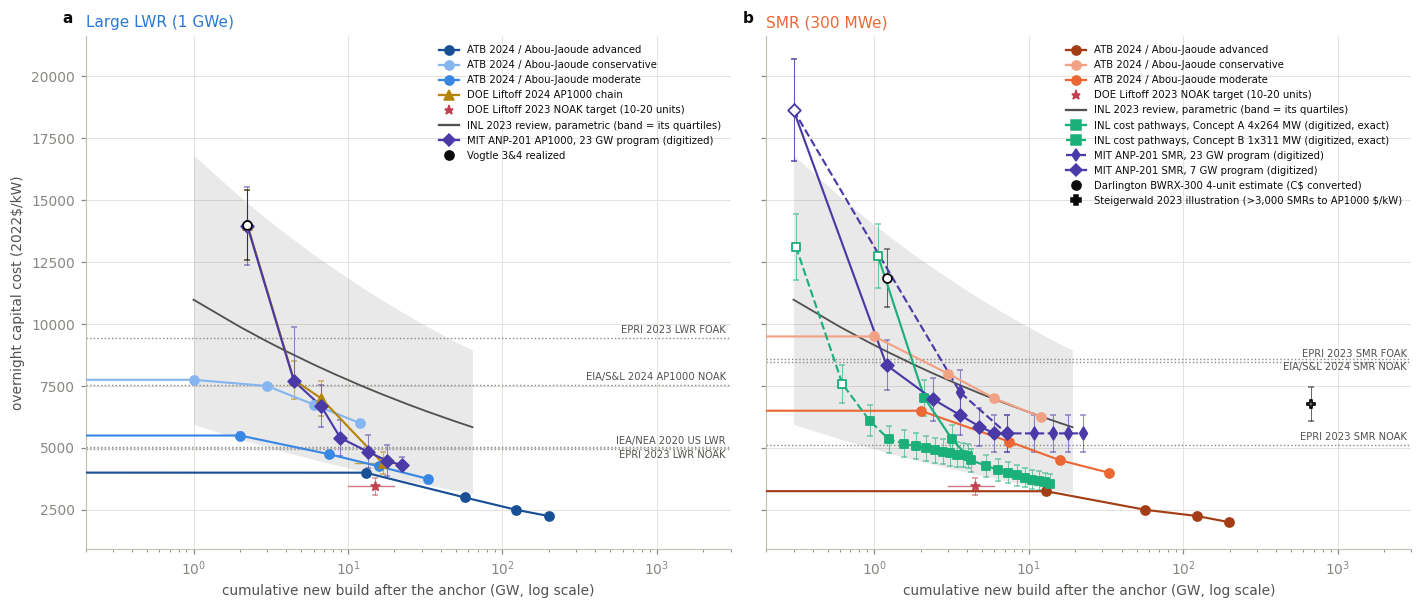

In [12]:
# Series styling (identity never rides on colour alone: every series is labelled in the legend).
STYLE = {
    "mit_ap1000_23gw": dict(color=ps.ACCENT["violet"], ls="-", marker="D", label="MIT ANP-201 AP1000, 23 GW program (digitized)"),
    "mit_smr_7gw":     dict(color=ps.ACCENT["violet"], ls="-", marker="D", label="MIT ANP-201 SMR, 7 GW program (digitized)"),
    "mit_smr_23gw":    dict(color=ps.ACCENT["violet"], ls="--", marker="d", label="MIT ANP-201 SMR, 23 GW program (digitized)"),
    "inl_pathways_A":  dict(color=ps.ACCENT["green"], ls="-", marker="s", label="INL cost pathways, Concept A 4x264 MW (digitized, exact)"),
    "inl_pathways_B":  dict(color=ps.ACCENT["green"], ls="--", marker="s", label="INL cost pathways, Concept B 1x311 MW (digitized, exact)"),
    "liftoff_ap1000":  dict(color=ps.ACCENT["gold"], ls="-", marker="^", label="DOE Liftoff 2024 AP1000 chain"),
    "liftoff_noak_target": dict(color=ps.ACCENT["red"], ls="none", marker="*", label="DOE Liftoff 2023 NOAK target (10-20 units)"),
    "inl_review":      dict(color=MUTED, ls="-", marker="", label="INL 2023 review, parametric (band = its quartiles)"),
    "steigerwald_parity": dict(color=INK, ls="none", marker="P", label="Steigerwald 2023 illustration (>3,000 SMRs to AP1000 $/kW)"),
    "vogtle_realized": dict(color=INK, ls="none", marker="o", label="Vogtle 3&4 realized"),
    "darlington_quote": dict(color=INK, ls="none", marker="o", label="Darlington BWRX-300 4-unit estimate (C$ converted)"),
}
for scen in SCEN_ORDER:
    STYLE[f"aj_{scen}"] = dict(color=None, ls="-", marker="o", label=f"ATB 2024 / Abou-Jaoude {scen}")
UNPAIRED_LABEL = {"eia_sl_large": "EIA/S&L 2024 AP1000", "eia_sl_smr": "EIA/S&L 2024 SMR",
                  "epri_large": "EPRI 2023 LWR", "epri_smr": "EPRI 2023 SMR", "iea_nea_large": "IEA/NEA 2020 US LWR"}

def series_color(sid, tech):
    return SCEN_COLOR[tech][sid[3:]] if sid.startswith("aj_") else STYLE[sid]["color"]

def draw_series(ax, g, tech, with_bands=True, x="cum_gw"):
    sid = g["series_id"].iloc[0]
    st = STYLE[sid]
    col = series_color(sid, tech)
    g = g.sort_values(x)
    if sid == "inl_review":
        ax.fill_between(g[x], g["occ_lo_2022"], g["occ_hi_2022"], color=col, alpha=0.12, lw=0)
        ax.plot(g[x], g["occ_2022"], color=col, ls=st["ls"], lw=1.2)
        return
    if st["ls"] != "none":
        ax.plot(g[x], g["occ_2022"], color=col, ls=st["ls"], lw=1.4, zorder=3)
    hollow = g["scored"] == 0
    for mask, fc in ((~hollow, col), (hollow, "white")):
        gg = g[mask]
        if len(gg):
            ax.scatter(gg[x], gg["occ_2022"], marker=st["marker"], s=34, facecolor=fc, edgecolor=col,
                       lw=1.2, zorder=4)
    if with_bands:
        ax.errorbar(g[x], g["occ_2022"], yerr=[g["occ_2022"] - g["occ_lo_2022"], g["occ_hi_2022"] - g["occ_2022"]],
                    fmt="none", ecolor=col, elinewidth=0.7, alpha=0.6, capsize=2, zorder=2)
        nb_ = g[g["n_lo"].notna()]
        if len(nb_) and x == "cum_gw":
            for r in nb_.itertuples():
                ax.plot([r.n_lo*r.cum_gw/r.n_units, r.n_hi*r.cum_gw/r.n_units], [r.occ_2022]*2,
                        color=col, lw=0.9, alpha=0.7)

# e01 - cost vs cumulative build, one panel per technology, all series
fig, axes = plt.subplots(1, 2, figsize=(ps.W3, 5.6), sharey=True)
for ax, tech in zip(axes, TECH):
    sub = pts[(pts.tech == tech) & pts.paired]
    for sid, g in sub.groupby("series_id", sort=False):
        draw_series(ax, g, tech)
    unp = pts[(pts.tech == tech) & ~pts.paired].sort_values("occ_2022")
    _last = -1e9
    for r in unp.itertuples():
        ax.axhline(r.occ_2022, color=FAINT, lw=0.9, ls=":", zorder=1)
        crowd = (r.occ_2022 - _last) < 450        # stagger labels closer than ~a text height
        ax.annotate(f"{UNPAIRED_LABEL[r.series_id]} {r.basis}" if r.basis in ("FOAK", "NOAK") else UNPAIRED_LABEL[r.series_id],
                    (3000.0, r.occ_2022), xytext=(-3, -2 if crowd else 2), textcoords="offset points", fontsize=6.5,
                    color=MUTED, ha="right", va="top" if crowd else "bottom")
        _last = r.occ_2022
    ax.set_xscale("log")
    ax.set_xlim(0.2, 3000.0)
    ax.set_xlabel("cumulative new build after the anchor (GW, log scale)")
    ax.set_title(TECH_LABEL[tech], color=TECH_COLOR[tech], loc="left", fontsize=10)
    handles = [Line2D([], [], color=series_color(s, tech), ls=STYLE[s]["ls"] if STYLE[s]["ls"] != "none" else "",
                      marker=STYLE[s]["marker"] or None, label=STYLE[s]["label"])
               for s in sub["series_id"].unique()]
    ax.legend(handles=handles, fontsize=6.6, loc="upper right", ncol=1)
axes[0].set_ylabel("overnight capital cost (2022$/kW)")
ps.panel_letter(axes[0], "a"); ps.panel_letter(axes[1], "b")
fig.tight_layout()
ps.savefig(fig, LIT_FIGURES / "e01_occ_vs_cumulative_build.png")
plt.show()


**e01 — cost against cumulative build** (`e01_occ_vs_cumulative_build.png`). **a** large reactors, **b** SMRs; x = cumulative new build after each source's anchor (GW, log), y = overnight capital cost in 2022 dollars. Connected series = sources that pair cost with a unit count; hollow markers = first- and second-of-a-kind points (never scored); vertical bars = each point's significance band; horizontal bars on the Liftoff points = the stated 10–20-unit range; dotted horizontal lines = sources with no deployment attached. The Abou-Jaoude trajectories are placed at his own deployment path (x = his new build after 2030), three per technology.

saved -> figures\e02_occ_vs_year.png


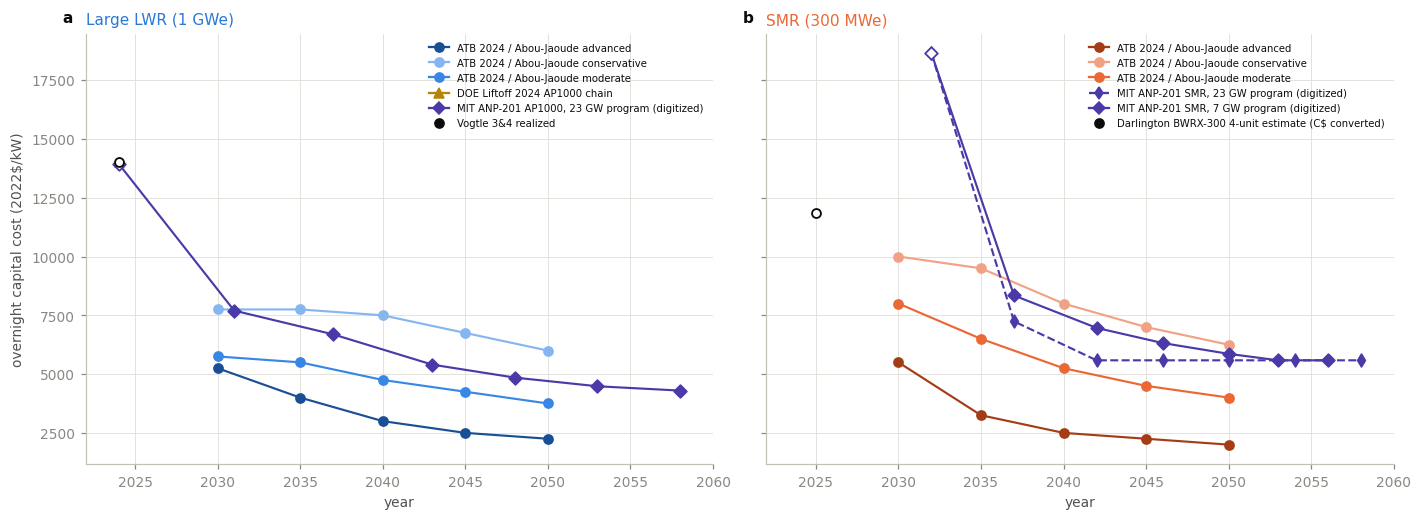

In [13]:
# e02 - the dated series against calendar year
fig, axes = plt.subplots(1, 2, figsize=(ps.W3, 4.8), sharey=True)
for ax, tech in zip(axes, TECH):
    sub = pts[(pts.tech == tech) & pts.paired & pts.dated]
    for sid, g in sub.groupby("series_id", sort=False):
        draw_series(ax, g, tech, with_bands=False, x="year")
    ax.set_xlim(2022, 2060)
    ax.set_xlabel("year")
    ax.set_title(TECH_LABEL[tech], color=TECH_COLOR[tech], loc="left", fontsize=10)
    handles = [Line2D([], [], color=series_color(s, tech), ls=STYLE[s]["ls"] if STYLE[s]["ls"] != "none" else "",
                      marker=STYLE[s]["marker"] or None, label=STYLE[s]["label"]) for s in sub["series_id"].unique()]
    ax.legend(handles=handles, fontsize=6.6, loc="upper right")
axes[0].set_ylabel("overnight capital cost (2022$/kW)")
ps.panel_letter(axes[0], "a"); ps.panel_letter(axes[1], "b")
fig.tight_layout()
ps.savefig(fig, LIT_FIGURES / "e02_occ_vs_year.png")
plt.show()


**e02 — the dated series against calendar year** (`e02_occ_vs_year.png`). Only sources that attach a year: the Abou-Jaoude milestones (2030–2050), MIT's offering years (2024–2058), and the realized or quoted projects. Undated series (INL pathways, Liftoff, the INL review) do not appear.

saved -> figures\e03_normalized_vs_doublings.png


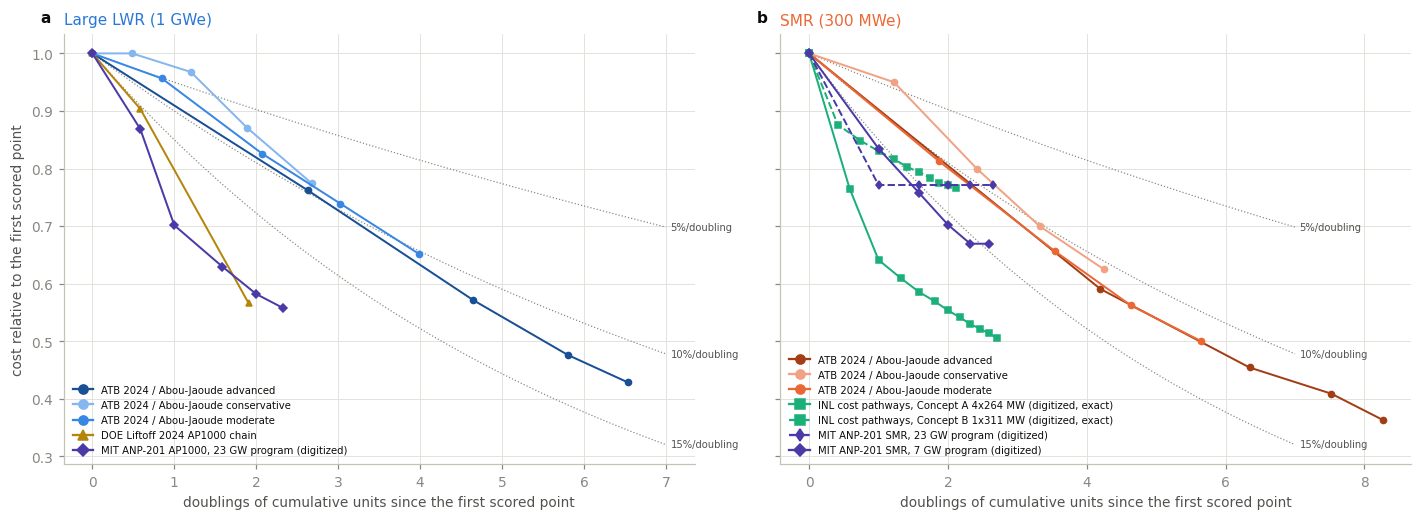

In [14]:
# e03 - normalized cost vs doublings of the unit count; slope = implied learning rate
fig, axes = plt.subplots(1, 2, figsize=(ps.W3, 4.8), sharey=True)
xx = np.linspace(0, 7, 50)
for ax, tech in zip(axes, TECH):
    for lr_ref in (0.05, 0.10, 0.15):
        ax.plot(xx, (1 - lr_ref)**xx, color=FAINT, lw=0.8, ls=":")
        ax.annotate(f"{lr_ref:.0%}/doubling", (xx[-1], (1 - lr_ref)**xx[-1]), xytext=(3, 0),
                    textcoords="offset points", fontsize=6.5, color=MUTED, va="center")
    sub = pts[(pts.tech == tech) & pts.paired & (pts.scored == 1)]
    handles = []
    for sid, g in sub.groupby("series_id", sort=False):
        g = g.sort_values("cum_gw")
        if len(g) < 2 or sid == "inl_review":
            continue
        nn = g["n_post"].values + N_BOAK_UNITS if sid.startswith("aj_") else g["n_units"].values
        nn = nn.astype(float)
        if nn[0] <= 0:
            continue
        col = series_color(sid, tech)
        st = STYLE[sid]
        ax.plot(np.log2(nn/nn[0]), g["occ_2022"].values/g["occ_2022"].values[0], color=col, ls=st["ls"],
                marker=st["marker"], ms=4, lw=1.3)
        handles.append(Line2D([], [], color=col, ls=st["ls"], marker=st["marker"], label=st["label"]))
    ax.set_xlabel("doublings of cumulative units since the first scored point")
    ax.set_title(TECH_LABEL[tech], color=TECH_COLOR[tech], loc="left", fontsize=10)
    ax.legend(handles=handles, fontsize=6.6, loc="lower left")
axes[0].set_ylabel("cost relative to the first scored point")
ps.panel_letter(axes[0], "a"); ps.panel_letter(axes[1], "b")
fig.tight_layout()
ps.savefig(fig, LIT_FIGURES / "e03_normalized_vs_doublings.png")
plt.show()


**e03 — normalized cost against doublings** (`e03_normalized_vs_doublings.png`). Each scored series divided by its first scored point and plotted against log2 of its unit count; a straight line is a constant learning rate, and the dotted references are 5, 10 and 15% per doubling. Abou-Jaoude's counts are post-anchor units plus the two anchor units (his own per-vendor count would divide by the vendor count and steepen the apparent slope). The implied per-segment rates are in `c03`.

**What e01–e03 show (read from `c02`/`c03`; every value 2022$/kW).**

- *Levels converge where the programs overlap.* Between about 10 and 30 GW of cumulative build, the large-reactor series pass through one window, roughly 4,000–6,000: the ATB moderate and conservative trajectories, MIT's AP1000 chain (4,300–4,900 at 12–20 units) and the Liftoff chain (4,400 at 10–20 units). The ATB advanced trajectory sits below every other series at every deployment it covers. The unpaired reference values (EIA/S&L 7,550, EPRI NOAK 5,050, IEA/NEA 4,950) fall inside the same window. The INL 2023 review's quartile band spans the whole set.
- *Shapes differ more than levels.* The single-design chains (MIT, Liftoff, INL pathways) fall steeply over their first doublings — implied 22–29% per doubling from the first scored point (`c03`) — and then flatten: MIT's SMR programs plateau near 5,600 after 24 units, INL's Concept A near 3,500 after ten plants. The Abou-Jaoude trajectories decline at a near-constant 9–12% per doubling with no plateau. The first shape is a first-of-a-kind-to-Nth-of-a-kind waterfall (overruns and rework eliminated in the first few plants); the second is a Wright curve. Both are stated model choices, not measurements.
- *SMR sources disagree most before 5 GW and least after 10 GW.* First-of-a-kind SMR values run 12,000–19,000 (MIT, INL, Darlington) against the ATB's 2030 anchors of 5,500–10,000; beyond 10 GW the SMR series sit within 3,500–6,000 of each other's plateaus and the ATB moderate curve.
- *Timing (e02).* Where sources attach years, MIT's AP1000 chain reaches the ATB moderate level about a decade later than the ATB places it (2048 vs 2040 for ~4,800), because MIT's program builds 23 GW by 2058 while the ATB moderate program builds 34 GW by 2050.


## Part C — where each projection sits in the engine's parameter space

**What we did.** For each series and each scored point, the closed-form engine gives the
cost shape (cost divided by the anchor cost) at that point's cumulative units, for every
one of the 113,400 grid worlds (learning rate × spillover × foreign deployment × vendor
count × experience base × combination rule). Because cost = anchor × shape, a world
reproduces a point when the anchor lies in [band low ÷ shape, band high ÷ shape]. A world
reproduces the *series* when those intervals intersect each other and the anchor prior
the Monte Carlo samples. That is the feasibility test; no fitting loop is involved. The
implied anchor interval is kept for each feasible world.

**Two reads of a single-design series (A2).** Read R1 places the source's cumulative
units as the national post-anchor build, spread by the engine across its m vendors: the
source is then the engine's one-vendor limit and should sit at or below the engine's
median. Read R2 gives each of the engine's vendors the source's own count. The Abou-
Jaoude series is scored under R1 only (its deployment is a national program). Undated
series are scored at 2050 (the Fig 1 basis) with 2030 as the bracket (A3).

**Gate G2** re-derives the sibling notebook's Abou-Jaoude feasible sets and endpoint
shares from this notebook's machinery and requires exact agreement.

**A caveat on the Abou-Jaoude rows.** Scoring all five milestones inside ±$125/kW is a
full-trajectory criterion, and a labelled sensitivity at the sibling's ±$250 tolerance is
reported next to it. Neither is the paper's S1 criterion, which is one-sided at the 2050
endpoint; the paper's shares are re-derived under gate G2 and are not restated here.


In [15]:
# The scoring machinery.
def score_series(g, tech, read, year_mode):
    """Feasibility of every grid world for the scored points of one series.
    Returns (feasible mask, implied BOAK lo, implied BOAK hi, nearest-miss $ in anchor dollars)."""
    B_lo = np.full(NG, -np.inf)
    B_hi = np.full(NG, np.inf)
    for r in g.itertuples():
        n = float(r.n_post) * (G["m"] if read == "R2" else 1.0)
        yr = min(int(r.year), 2050) if pd.notna(r.year) else (2050 if year_mode == "2050" else 2030)   # A3: post-2050 -> 2050 stock
        sh = shape_at(tech, G["lr"], G["s"], G["u"], G["m"], G["conv"], G["rho"], n, yr)
        if year_mode == "dated (+-250)":              # AJ sensitivity: the sibling's trajectory tolerance
            lo_k, hi_k = r.occ_2022 - 250.0, r.occ_2022 + 250.0
        else:
            lo_k, hi_k = r.occ_lo_2022, r.occ_hi_2022
        B_lo = np.maximum(B_lo, lo_k/sh)
        B_hi = np.minimum(B_hi, hi_k/sh)
    lo = np.maximum(B_lo, TECH[tech]["boak_lo"])
    hi = np.minimum(B_hi, TECH[tech]["boak_hi"])
    feas = lo <= hi
    return feas, lo, hi, np.where(feas, 0.0, lo - hi)

SERIES = [(sid, tech, g) for (sid, tech), g in pts[pts.paired & (pts.scored == 1)].groupby(["series_id", "tech"], sort=False)]
RUNS = []             # (sid, tech, read, year_mode) -> results
for sid, tech, g in SERIES:
    reads = ["R1"] if sid.startswith("aj_") else ["R1", "R2"]
    modes = (["dated", "dated (+-250)"] if sid.startswith("aj_") else ["dated"]) if g["dated"].all() else ["2050", "2030"]
    for read in reads:
        for mode in modes:
            RUNS.append((sid, tech, read, mode))
RES = {}
_t0 = _time.time()
for key in RUNS:
    sid, tech, read, mode = key
    g = [x for x in SERIES if x[0] == sid and x[1] == tech][0][2]
    RES[key] = score_series(g, tech, read, mode)
print(f"scored {len(RUNS)} series x read x year-mode combinations on {NG:,} worlds in {_time.time()-_t0:.0f}s")

_rows, _rng5 = [], []
_q = lambda a: (np.nan,)*5 if a.size == 0 else tuple(np.quantile(a, [0, .25, .5, .75, 1]))
DIALS = {"lr": G["lr"], "s": G["s"], "u": G["u"], "m": G["m"], "conv": G["conv"], "rho": G["rho"]}
for key in RUNS:
    sid, tech, read, mode = key
    feas, lo, hi, miss = RES[key]
    sup = SUPPORT[tech]
    g = [x for x in SERIES if x[0] == sid and x[1] == tech][0][2]
    _rows.append(dict(series_id=sid, tech=tech, read=read, year_mode=mode, n_points=len(g),
                      n_feasible=int(feas.sum()), share_grid=feas.mean(), share_support=feas[sup].mean(),
                      share_support_fresh=feas[sup & (G["conv"] == 0)].mean(),
                      share_support_legacy=feas[sup & (G["conv"] == 1)].mean(),
                      nearest_miss_usd=(0.0 if feas.any() else float(miss.min()))))
    row = dict(series_id=sid, tech=tech, read=read, year_mode=mode, n_feasible=int(feas.sum()))
    for d, arr in DIALS.items():
        row.update(dict(zip([f"{d}_min", f"{d}_q25", f"{d}_med", f"{d}_q75", f"{d}_max"], _q(arr[feas]))))
    row.update(dict(zip(["boak_min", "boak_q25", "boak_med", "boak_q75", "boak_max"],
                        _q(0.5*(lo[feas] + hi[feas])))))
    row["boak_interval_min"] = float(lo[feas].min()) if feas.any() else np.nan
    row["boak_interval_max"] = float(hi[feas].max()) if feas.any() else np.nan
    _rng5.append(row)
c04 = pd.DataFrame(_rows)
c05 = pd.DataFrame(_rng5)
c04.to_csv(LIT_EXPORTS / "c04_feasible_shares.csv", index=False)
c05.to_csv(LIT_EXPORTS / "c05_parameter_ranges.csv", index=False)
c05[["series_id", "tech", "read", "year_mode", "n_feasible", "boak_interval_min", "boak_interval_max", "boak_med"]] \
    .to_csv(LIT_EXPORTS / "c07_implied_boak.csv", index=False)
for key in RUNS:                                                                        # K3
    sid, tech, read, mode = key
    if not RES[key][0].any():
        VERDICT.append(("kill", "K3", "OUTSIDE-SAMPLED-SPACE",
                        f"{sid}/{tech}/{read}/{mode}: no feasible world; nearest miss ${RES[key][3].min():,.0f} of anchor"))
print("\nc04 - feasible-world shares per series x read x year mode (share_support = within the MC's "
      "sampled learning-rate support) -> exports/c04_feasible_shares.csv")
print(c04.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print("\nc05 - dial ranges over the feasible set (min / median / max shown) -> exports/c05_parameter_ranges.csv")
_short = c05[["series_id", "tech", "read", "year_mode", "n_feasible"] +
             [f"{d}_{q}" for d in ("lr", "s", "u", "m", "conv") for q in ("min", "med", "max")] +
             ["boak_interval_min", "boak_interval_max"]]
print(_short.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))


scored 46 series x read x year-mode combinations on 113,400 worlds in 5s

c04 - feasible-world shares per series x read x year mode (share_support = within the MC's sampled learning-rate support) -> exports/c04_feasible_shares.csv
          series_id  tech read     year_mode  n_points  n_feasible  share_grid  share_support  share_support_fresh  share_support_legacy  nearest_miss_usd
        aj_advanced large   R1         dated         5         485      0.0043         0.0004               0.0007                0.0000            0.0000
        aj_advanced large   R1 dated (+-250)         5        3500      0.0309         0.0045               0.0091                0.0000            0.0000
    aj_conservative large   R1         dated         5           0      0.0000         0.0000               0.0000                0.0000          149.7848
    aj_conservative large   R1 dated (+-250)         5          87      0.0008         0.0000               0.0000                0.0000            0

In [16]:
# G2 - the Abou-Jaoude regression against the sibling's exports, on the sibling's Part-1 grid.
_mesh = np.meshgrid(LR_GRID, S21, U21, indexing="ij")
LRv, Sv, Uv = (a.ravel() for a in _mesh)
NPTS = LRv.size
P1 = {"lr": np.tile(LRv, len(DISC_COMBOS)), "s": np.tile(Sv, len(DISC_COMBOS)), "u": np.tile(Uv, len(DISC_COMBOS)),
      "ces_rho": np.repeat([c[0] for c in DISC_COMBOS], NPTS),
      "conv_full": np.repeat([c[1] for c in DISC_COMBOS], NPTS),
      "n_vendors": np.repeat([c[2] for c in DISC_COMBOS], NPTS)}
TOL, TOL_END = 250.0, 125.0
end_share = pd.read_csv(ATB_OUT / "endpoint_feasible_share.csv").set_index(["tech", "scenario"])
_rows = []
_t0 = _time.time()
for tech in TECH:
    sup = (P1["lr"] >= TECH[tech]["lr_lo"]) & (P1["lr"] <= TECH[tech]["lr_hi"])
    for scen in SCEN_ORDER:
        boak = float(ATB_T[(tech, scen)].loc[2030])
        pred = {}
        for y in MILESTONES[1:]:
            n = aj_units_entering(scen, tech, y)
            pred[y] = boak * shape_at(tech, P1["lr"], P1["s"], P1["u"], P1["n_vendors"], P1["conv_full"],
                                      P1["ces_rho"], n, y)
        mis = np.max([np.abs(pred[y] - float(ATB_T[(tech, scen)].loc[y])) for y in MILESTONES[1:]], axis=0)
        feas = mis <= TOL
        ref = pd.read_csv(ATB_OUT / f"feasible_set_{tech}_{scen}.csv.gz")
        mine = pd.DataFrame({k: P1[k][feas] for k in P1})
        key = ["lr", "s", "u", "ces_rho", "conv_full", "n_vendors"]
        merged = mine.round(4).merge(ref[key].round(4), on=key, how="outer", indicator=True)
        same = (len(mine) == len(ref)) and (merged["_merge"] == "both").all()
        t50 = float(ATB_T[(tech, scen)].loc[2050])
        gap = np.maximum(pred[2050] - t50, 0.0) <= TOL_END
        two = np.abs(pred[2050] - t50) <= TOL_END
        e = end_share.loc[(tech, scen)]
        ok_end = (abs(round(gap.mean(), 4) - e["share_grid"]) < 1e-4 and
                  abs(round(gap[sup].mean(), 4) - e["share_support"]) < 1e-4 and
                  abs(round(two[sup].mean(), 4) - e["share_support_twosided"]) < 1e-4)
        _rows.append(dict(tech=tech, scenario=scen, n_feasible_mine=len(mine), n_feasible_sibling=len(ref),
                          set_identical=bool(same), share_grid_mine=round(gap.mean(), 4), share_grid_sibling=e["share_grid"],
                          share_support_mine=round(gap[sup].mean(), 4), share_support_sibling=e["share_support"],
                          twosided_mine=round(two[sup].mean(), 4), twosided_sibling=e["share_support_twosided"],
                          endpoint_shares_match=bool(ok_end)))
c06 = pd.DataFrame(_rows)
c06.to_csv(LIT_EXPORTS / "c06_aj_regression.csv", index=False)
print(f"G2 regression on {NPTS*len(DISC_COMBOS):,} worlds in {_time.time()-_t0:.0f}s -> exports/c06_aj_regression.csv")
print(c06.to_string(index=False))
assert c06["set_identical"].all() and c06["endpoint_shares_match"].all(), "G2 FAILED"
print("G2 PASSED: feasible sets identical to the sibling's exports (6/6) and endpoint shares match to 4 dp")
VERDICT.append(("gate", "G2", "PASS", "AJ feasible sets + endpoint shares reproduce mc/exports/atb exactly"))


G2 regression on 793,800 worlds in 5s -> exports/c06_aj_regression.csv
 tech     scenario  n_feasible_mine  n_feasible_sibling  set_identical  share_grid_mine  share_grid_sibling  share_support_mine  share_support_sibling  twosided_mine  twosided_sibling  endpoint_shares_match
large conservative              403                 403           True           0.2784              0.2784              0.0570                 0.0570         0.0247            0.0247                   True
large     moderate            41190               41190           True           0.2754              0.2754              0.0189                 0.0189         0.0149            0.0149                   True
large     advanced            19789               19789           True           0.2769              0.2769              0.0011                 0.0011         0.0011            0.0011                   True
  smr conservative             4621                4621           True           0.4559              

In [17]:
# G3 - self-consistency: the full engine, run on a path that delivers each point's stock, lands
# inside the point's band for 8 random feasible worlds per scored series (primary read/mode).
_rng3 = rng_stream("lit/g3")
_worst, _checked = 0.0, 0
for key in RUNS:
    sid, tech, read, mode = key
    if mode in ("2030", "dated (+-250)") or read == "R2":
        continue
    feas, lo, hi, _ = RES[key]
    idx = np.flatnonzero(feas)
    if idx.size == 0:
        continue
    g = [x for x in SERIES if x[0] == sid and x[1] == tech][0][2]
    for w in _rng3.choice(idx, size=min(8, idx.size), replace=False):
        boak = 0.5*(lo[w] + hi[w])
        w1 = make_worlds([G["lr"][w]], boak, [G["u"][w]], [G["s"][w]], [G["m"][w]], [G["conv"][w]], [G["rho"][w]])
        for r in g.itertuples():
            yr = min(int(r.year), 2050) if pd.notna(r.year) else 2050
            n_end = float(r.n_post)
            ramp = np.where(YEARS <= ANCHOR, 0.0, np.minimum((YEARS - ANCHOR)/(yr - 1 - ANCHOR), 1.0)) * n_end \
                if yr - 1 > ANCHOR else np.zeros(T)
            occ = occ_paths_ces(w1, tech, ramp)[0, yi(yr)]
            _worst = max(_worst, max(r.occ_lo_2022 - occ, occ - r.occ_hi_2022, 0.0))
            _checked += 1
assert _worst < 1e-6, _worst
print(f"G3 PASSED: {_checked} (world, point) checks; the full engine never leaves the band the closed form "
      f"placed it in (worst excursion ${_worst:.1e})")
VERDICT.append(("gate", "G3", "PASS", f"{_checked} full-engine checks inside band"))


G3 PASSED: 504 (world, point) checks; the full engine never leaves the band the closed form placed it in (worst excursion $0.0e+00)


saved -> figures\e04_feasible_lr_s_maps.png


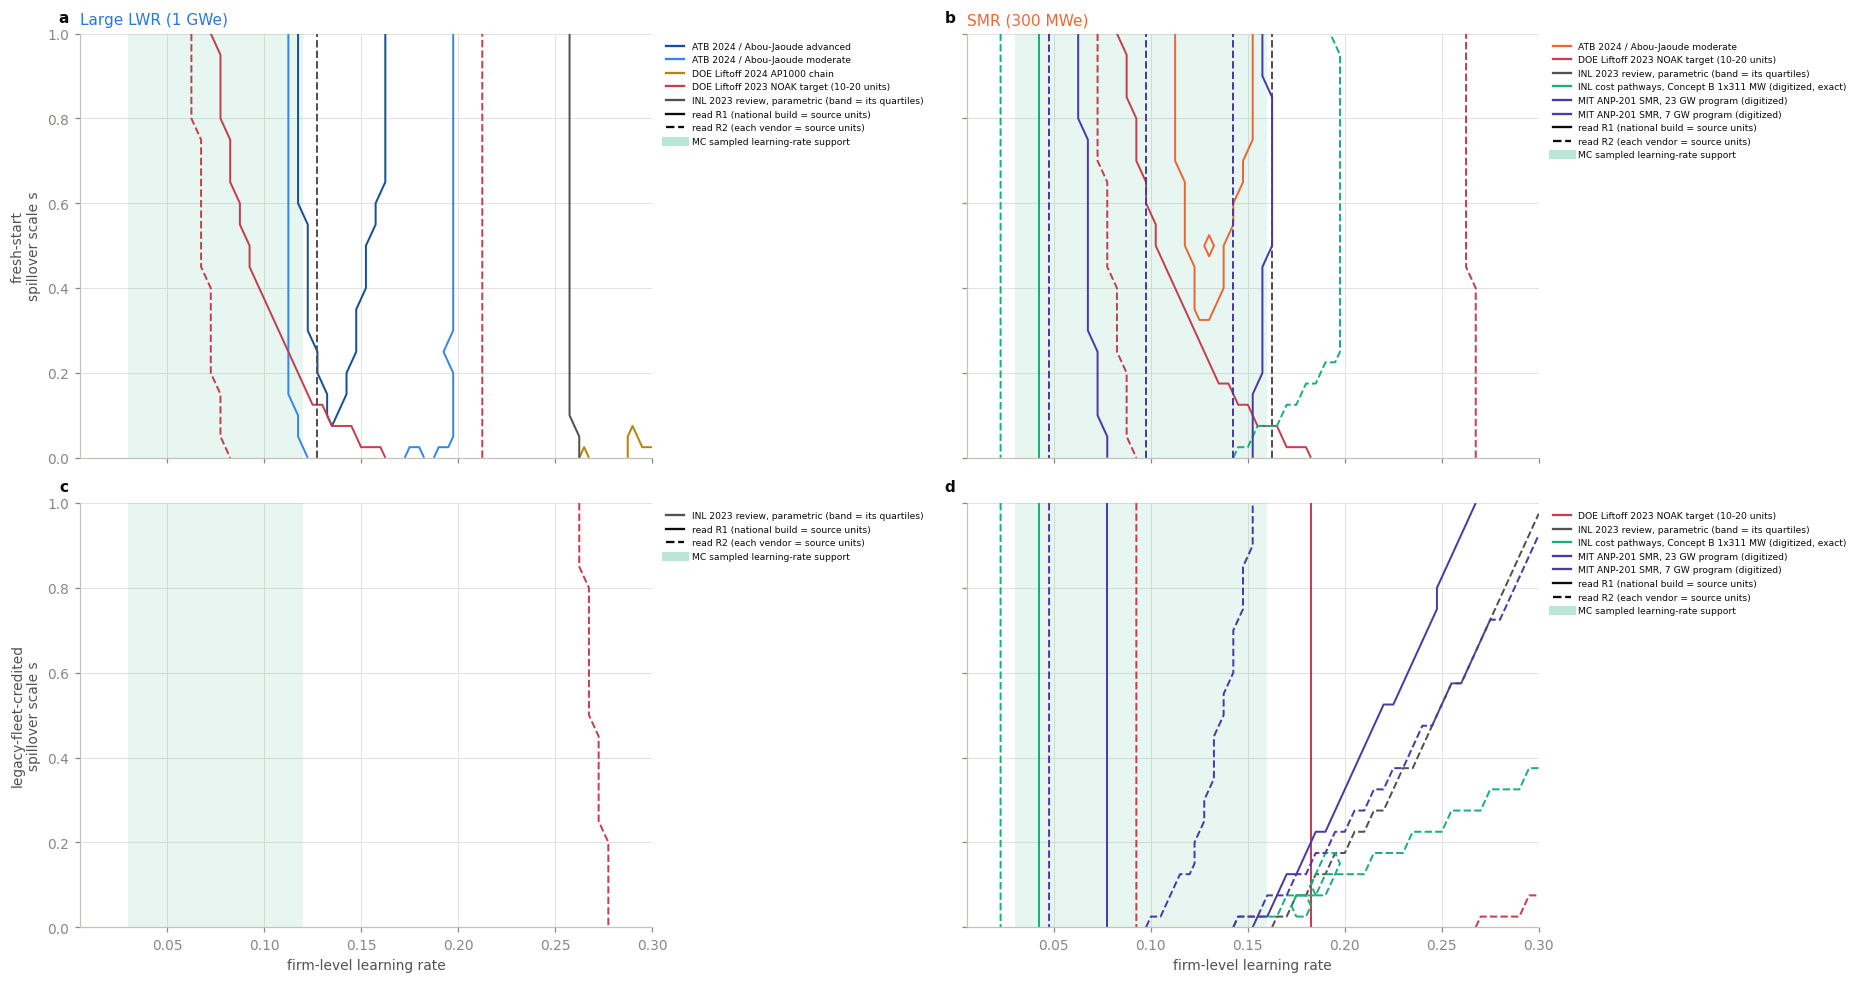

In [18]:
# e04 - where each series lives in the (learning rate, spillover) plane: the feasible region of
# each series (any u, m, rho) outlined per experience base; R1 solid, R2 dashed.
def lr_s_region(feas, conv):
    z = feas.reshape(G_SHAPE)            # (rho, conv, m, lr, s, u)
    return z[:, int(conv)].any(axis=(0, 1, 4))     # (rho, m, lr, s, u) -> any over rho, m, u -> (lr, s)

fig, axes = plt.subplots(2, 2, figsize=(ps.W3 + 4, 9.0), sharex=True, sharey=True)
for c_, tech in enumerate(TECH):
    for r_, conv in enumerate(CONV_GRID):
        ax = axes[r_, c_]
        ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=ps.C_TINY, alpha=0.10, lw=0)
        handles = []
        for key in RUNS:
            sid, t, read, mode = key
            if t != tech or mode in ("2030", "dated (+-250)"):
                continue
            Z = lr_s_region(RES[key][0], conv)
            if not Z.any():
                continue
            col = series_color(sid, tech)
            ls = "-" if read == "R1" else "--"
            ax.contour(LR_GRID, S21, Z.T.astype(float), levels=[0.5], colors=[col], linestyles=[ls], linewidths=1.3)
            if read == "R1":
                handles.append(Line2D([], [], color=col, label=STYLE[sid]["label"]))
        if r_ == 0:
            ax.set_title(TECH_LABEL[tech], color=TECH_COLOR[tech], loc="left", fontsize=10)
        if c_ == 0:
            ax.set_ylabel(("fresh-start" if conv == 0 else "legacy-fleet-credited") + "\nspillover scale s")
        if r_ == 1:
            ax.set_xlabel("firm-level learning rate")
        handles += [Line2D([], [], color=INK, ls="-", label="read R1 (national build = source units)"),
                    Line2D([], [], color=INK, ls="--", label="read R2 (each vendor = source units)"),
                    Line2D([], [], color=ps.C_TINY, lw=6, alpha=0.3, label="MC sampled learning-rate support")]
        ax.legend(handles=handles, fontsize=6.0, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ps.letter_panels(axes.ravel())
fig.tight_layout()
ps.savefig(fig, LIT_FIGURES / "e04_feasible_lr_s_maps.png")
plt.show()


**e04 — feasible regions in the (learning rate, spillover) plane** (`e04_feasible_lr_s_maps.png`). Each outline encloses the grid points where some setting of the other dials (foreign deployment, vendor count, combination rule, anchor within the prior) reproduces the whole series inside its bands; rows = experience base; solid = read R1, dashed = read R2; green band = the learning-rate support the Monte Carlo samples. A series with no outline in a panel has no feasible world there (listed under K3 in the verdict).

saved -> figures\e05_dial_marginals.png


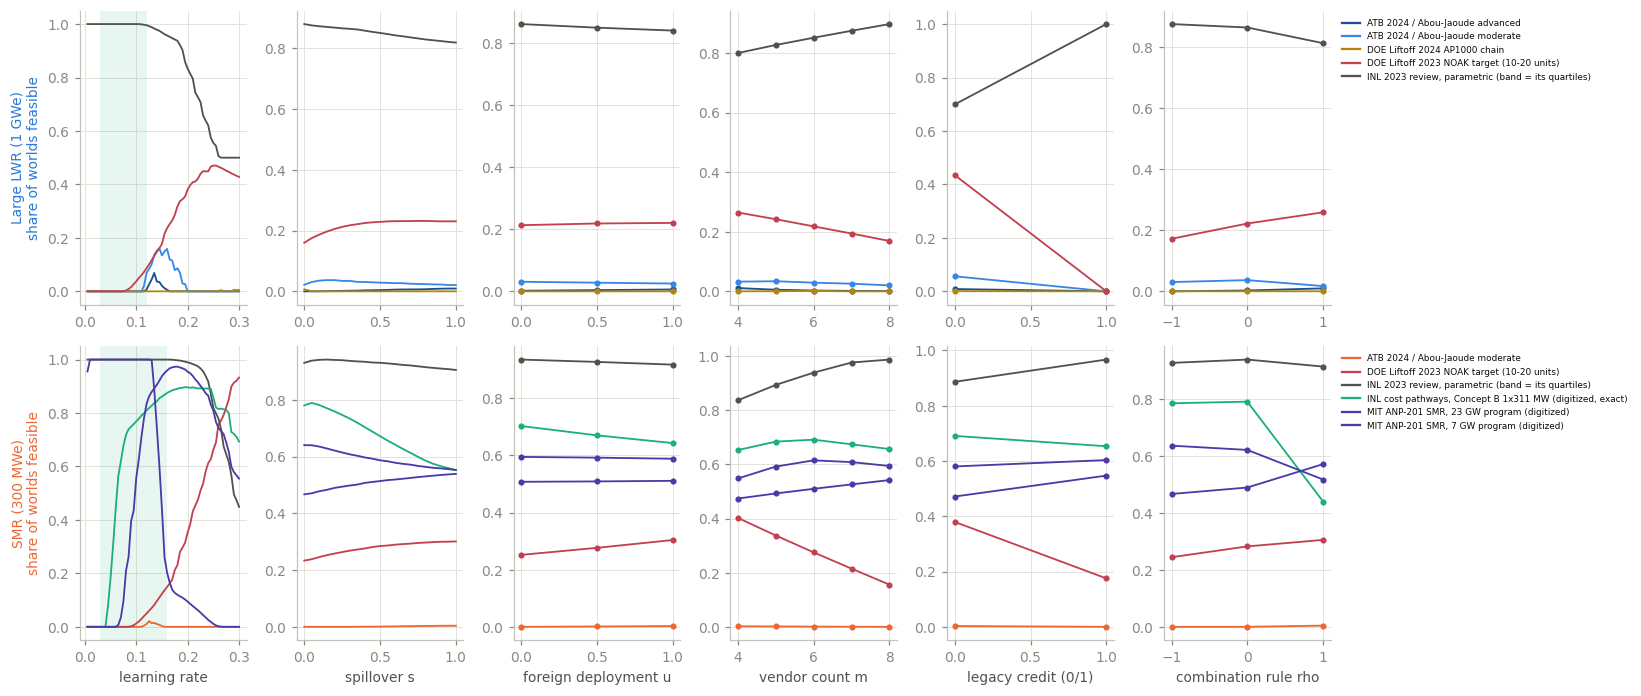

In [19]:
# e05 - dial marginals (F4-style): share of feasible worlds by dial value, per series (R1, primary mode).
fig, axes = plt.subplots(2, 6, figsize=(ps.W3 + 2, 6.4))
for r_, tech in enumerate(TECH):
    handles = []
    for key in RUNS:
        sid, t, read, mode = key
        if t != tech or read != "R1" or mode in ("2030", "dated (+-250)"):
            continue
        feas = RES[key][0]
        if not feas.any():
            continue
        col = series_color(sid, tech)
        for c_, (d, arr) in enumerate(DIALS.items()):
            vals = np.unique(arr)
            share = np.array([feas[arr == v].mean() for v in vals])
            ax = axes[r_, c_]
            ax.plot(vals, share, color=col, lw=1.2, marker="." if len(vals) < 10 else None)
        handles.append(Line2D([], [], color=col, label=STYLE[sid]["label"]))
    for c_, d in enumerate(DIALS):
        ax = axes[r_, c_]
        if r_ == 1:
            ax.set_xlabel({"lr": "learning rate", "s": "spillover s", "u": "foreign deployment u",
                           "m": "vendor count m", "conv": "legacy credit (0/1)", "rho": "combination rule rho"}[d])
        if c_ == 0:
            ax.set_ylabel(f"{TECH_LABEL[tech]}\nshare of worlds feasible", color=TECH_COLOR[tech])
        if d == "lr":
            ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=ps.C_TINY, alpha=0.10, lw=0)
    axes[r_, -1].legend(handles=handles, fontsize=5.8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
ps.savefig(fig, LIT_FIGURES / "e05_dial_marginals.png")
plt.show()


**e05 — which dials each series pins** (`e05_dial_marginals.png`). For each dial value, the share of grid worlds holding that value that reproduce the series (read R1, dated or 2050 mode). A flat profile means the series carries no information about that dial; a peaked profile means it pins it.

saved -> figures\e06_projections_on_cost_plane.png


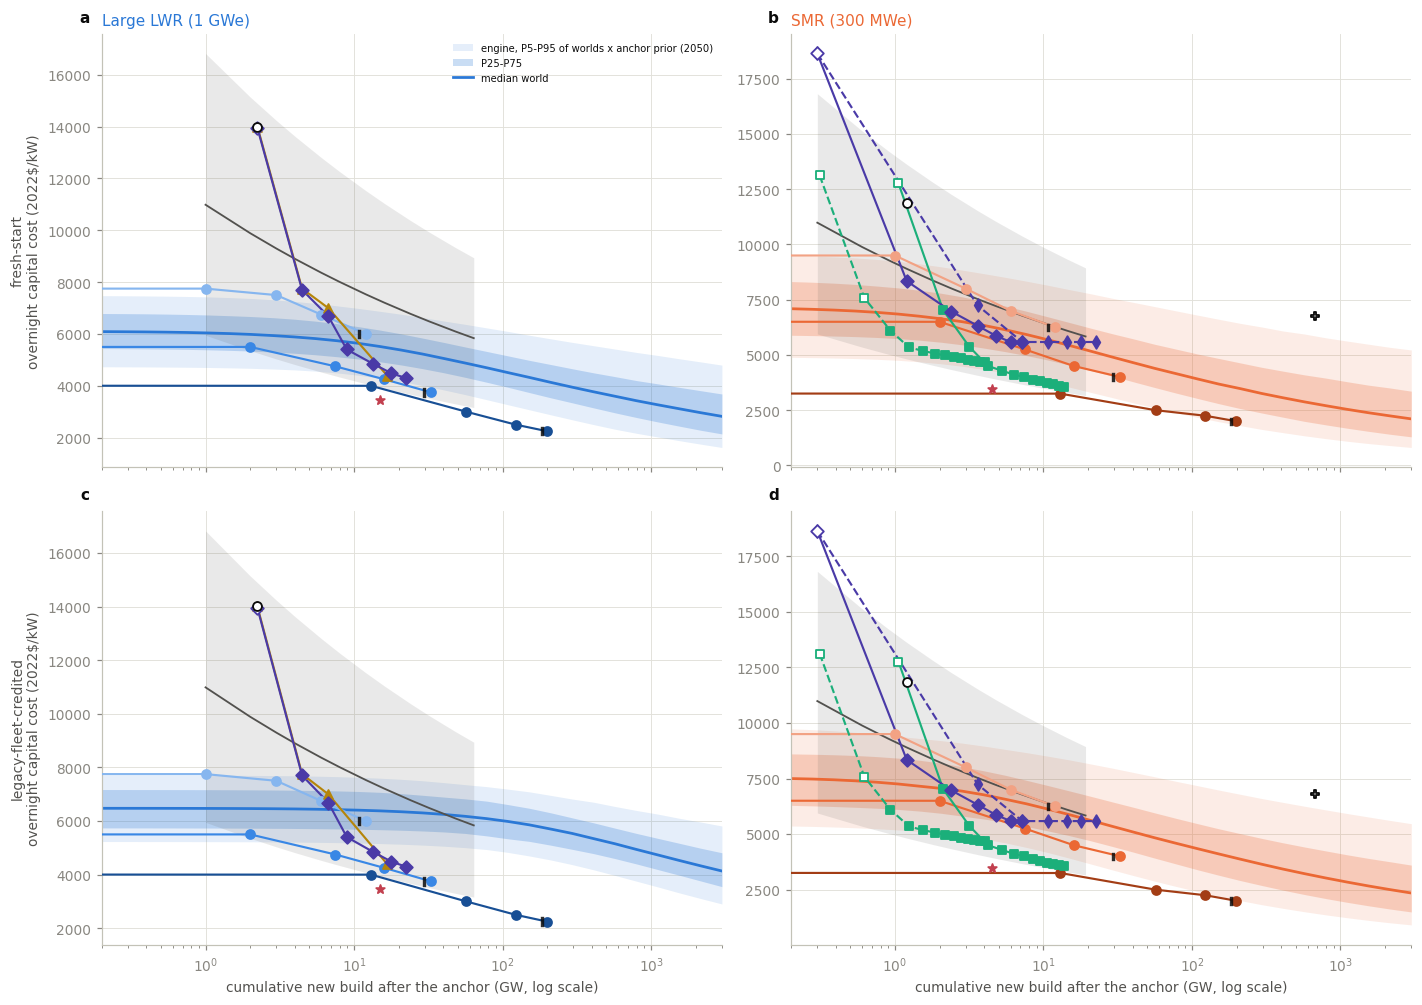

In [20]:
# e06 - every series on the engine's cost-deployment plane (Fig 1's construction, one panel per
# technology x experience base): fans over the support-restricted worlds AND the anchor prior.
D_PLANE_GW = np.logspace(np.log10(0.2), np.log10(3000.0), 30)
BOAK_Q = {t: np.linspace(TECH[t]["boak_lo"], TECH[t]["boak_hi"], 11) for t in TECH}
fig, axes = plt.subplots(2, 2, figsize=(ps.W3, 9.2), sharex=True)
for c_, tech in enumerate(TECH):
    for r_, conv in enumerate(CONV_GRID):
        ax = axes[r_, c_]
        strat = SUPPORT[tech] & (G["conv"] == conv)
        q = np.empty((len(D_PLANE_GW), 5))
        for k, d in enumerate(D_PLANE_GW):
            sh = shape_2050(tech, G["lr"][strat], G["s"][strat], G["u"][strat], G["m"][strat], conv,
                            G["rho"][strat], d / TECH[tech]["unit_gw"])
            q[k] = np.quantile(np.outer(BOAK_Q[tech], sh).ravel(), [0.05, 0.25, 0.5, 0.75, 0.95])
        ax.fill_between(D_PLANE_GW, q[:, 0], q[:, 4], color=TECH_COLOR[tech], alpha=0.12, lw=0,
                        label="engine, P5-P95 of worlds x anchor prior (2050)")
        ax.fill_between(D_PLANE_GW, q[:, 1], q[:, 3], color=TECH_COLOR[tech], alpha=0.25, lw=0, label="P25-P75")
        ax.plot(D_PLANE_GW, q[:, 2], color=TECH_COLOR[tech], lw=1.8, label="median world")
        sub = pts[(pts.tech == tech) & pts.paired]
        for sid, g in sub.groupby("series_id", sort=False):
            draw_series(ax, g, tech, with_bands=False)
        for scen in SCEN_ORDER:
            t50 = float(ATB_T[(tech, scen)].loc[2050])
            ax.plot([AJ_GW_ENT50[scen]]*2, [t50 - 125, t50 + 125], color=INK, lw=2.2, alpha=0.85, zorder=5)
        ax.set_xscale("log")
        ax.set_xlim(0.2, 3000.0)
        if r_ == 0:
            ax.set_title(TECH_LABEL[tech], color=TECH_COLOR[tech], loc="left", fontsize=10)
        if c_ == 0:
            ax.set_ylabel(("fresh-start" if conv == 0 else "legacy-fleet-credited") + "\novernight capital cost (2022$/kW)")
        if r_ == 1:
            ax.set_xlabel("cumulative new build after the anchor (GW, log scale)")
        if r_ == 0 and c_ == 0:
            ax.legend(fontsize=6.5, loc="upper right")
ps.letter_panels(axes.ravel())
fig.tight_layout()
ps.savefig(fig, LIT_FIGURES / "e06_projections_on_cost_plane.png")
plt.show()


**e06 — the projections on the engine's cost–deployment plane** (`e06_projections_on_cost_plane.png`). Fans = the 2050 cost the support-restricted grid worlds deliver at each cumulative build, with the anchor drawn uniformly across the Monte Carlo's 2030 anchor prior (P5–P95, P25–P75, median); rows = experience base. Every literature series is overlaid at its own cumulative build (read R1); the black bars are the three ATB 2050 targets ±$125/kW at their paired deployments, as in the paper's Fig 1. This is the SF-twin candidate for Fig 1.

In [21]:
# Plain-language reading per series, generated from c04/c05 (primary read/mode).
def _fmt_range(row, d, pct=False):
    lo, hi = row[f"{d}_min"], row[f"{d}_max"]
    return f"{lo:.1%}-{hi:.1%}" if pct else f"{lo:g}-{hi:g}"
print("Per-series reading (read R1; dated or 2050 mode; feasible-set ranges over the whole grid):\n")
for key in RUNS:
    sid, tech, read, mode = key
    if read != "R1" or mode == "2030":
        continue
    if mode == "dated (+-250)":
        a = c04[(c04.series_id == sid) & (c04.tech == tech) & (c04.read == read) & (c04.year_mode == mode)].iloc[0]
        print(f"    (at the sibling's +-$250 trajectory tolerance: {a.n_feasible:,} feasible worlds, {a.share_support:.1%} of the support)")
        continue
    a = c04[(c04.series_id == sid) & (c04.tech == tech) & (c04.read == read) & (c04.year_mode == mode)].iloc[0]
    b = c05[(c05.series_id == sid) & (c05.tech == tech) & (c05.read == read) & (c05.year_mode == mode)].iloc[0]
    r2 = c04[(c04.series_id == sid) & (c04.tech == tech) & (c04.read == "R2") & (c04.year_mode == mode)]
    r2s = f"; under R2 {r2.iloc[0].share_support:.1%} of the support" if len(r2) else ""
    if a.n_feasible == 0:
        print(f"- {STYLE[sid]['label']} [{tech}]: no feasible world (nearest miss ${a.nearest_miss_usd:,.0f} of anchor){r2s}.")
        continue
    print(f"- {STYLE[sid]['label']} [{tech}]: {a.n_feasible:,} feasible worlds ({a.share_grid:.1%} of the grid, "
          f"{a.share_support:.1%} of the sampled LR support; fresh-start {a.share_support_fresh:.1%}, "
          f"legacy-credited {a.share_support_legacy:.1%}){r2s}. Learning rate {_fmt_range(b, 'lr', True)}, "
          f"spillover {_fmt_range(b, 's')}, vendors {_fmt_range(b, 'm')}, anchor "
          f"${b.boak_interval_min:,.0f}-{b.boak_interval_max:,.0f}/kW.")


Per-series reading (read R1; dated or 2050 mode; feasible-set ranges over the whole grid):

- ATB 2024 / Abou-Jaoude advanced [large]: 485 feasible worlds (0.4% of the grid, 0.0% of the sampled LR support; fresh-start 0.1%, legacy-credited 0.0%). Learning rate 12.0%-16.0%, spillover 0.1-1, vendors 4-8, anchor $5,250-5,375/kW.
    (at the sibling's +-$250 trajectory tolerance: 3,500 feasible worlds, 0.5% of the support)
- ATB 2024 / Abou-Jaoude conservative [large]: no feasible world (nearest miss $150 of anchor).
    (at the sibling's +-$250 trajectory tolerance: 87 feasible worlds, 0.0% of the support)
- ATB 2024 / Abou-Jaoude moderate [large]: 3,197 feasible worlds (2.8% of the grid, 0.5% of the sampled LR support; fresh-start 0.9%, legacy-credited 0.0%). Learning rate 11.5%-19.5%, spillover 0-1, vendors 4-8, anchor $5,625-5,875/kW.
    (at the sibling's +-$250 trajectory tolerance: 12,474 feasible worlds, 5.4% of the support)
- DOE Liftoff 2024 AP1000 chain [large]: 37 feasible worl

**What Part C shows (read from `c04`/`c05`; shares are of the grid restricted to the Monte Carlo's learning-rate support unless stated).**

- *The Abou-Jaoude trajectories, scored at ±$125/kW at all five milestones, are reproduced by few worlds:* 0–0.5% of the support (large advanced 485 grid worlds at learning rates 12–16%; large moderate 3,197 at 11.5–19.5%; SMR moderate 162 at 11.5–15%; the other three none, nearest misses $150–220 of anchor). At the sibling's ±$250 trajectory tolerance the sets are 33–12,474 worlds. This is the same designed difference S1 reports: the engine prices post-2030 experience from each vendor's second unit, while the source attaches its anchor earlier in the build sequence (Methods §2, SN7, ST12). It is not the paper's S1 criterion, which is one-sided at the 2050 endpoint.
- *Single-design large-reactor chains are outside the sampled space.* MIT's AP1000 chain has no feasible world under either read (nearest miss $89 of anchor under R1); the Liftoff chain has 37 grid worlds under R1, all at learning rates of 26.5–30% with no spillover, and none under R2. Their first-scored-to-NOAK slopes (22–26% per doubling) lie above the engine's large-reactor support (3–12%). A waterfall of eliminated overruns is not something a constant-rate curve can trace.
- *The Liftoff NOAK target depends on the read by an order of magnitude.* $3,600/kW after 10–20 units is reached by 1.9% (large) and 3.7% (SMR) of the support under R1, and by 24% and 46% under R2. R1 treats the 10–20 units as the whole national program; R2 gives each of the engine's vendors that many units.
- *SMR series with a plateau are reproduced broadly.* MIT's 7 and 23 GW programs and INL's Concept B are feasible in 45–89% of the support because their plateaus (5,600–6,000 with ±10% bands, or the exact Concept B series) are broad enough for the engine's slower decline to cross; the dial marginals (e05) show these series bound the learning rate from above (roughly ≤15%) and say little about the other dials. INL's Concept A (a steeper waterfall to 3,500) has no feasible world (nearest miss $151 of anchor).
- *The INL 2023 review's quartile band admits almost every world* (≥99% of the support). It carries no information about the dials; it is a range statement, not a projection.
- *Experience base.* Legacy-fleet-credited worlds reproduce no large-reactor series (the credit flattens the large curve too much) but do reproduce the SMR plateaus.


## Verdict and manifest

Every gate and kill disposition is written to `c99_verdict.csv`; `lit_manifest.json`
records the seed, grids, tolerance rules, assumption register, the sha256 of every
ported engine cell, and a crc32 of every input and every file this notebook wrote.


In [22]:
c99 = pd.DataFrame(VERDICT, columns=["kind", "name", "result", "detail"])
c99.to_csv(LIT_EXPORTS / "c99_verdict.csv", index=False)
print(c99.to_string(index=False))

def _crc(path):
    return f"{zlib.crc32(Path(path).read_bytes()):08x}"

written = sorted(LIT_EXPORTS.glob("c*.csv")) + sorted(LIT_FIGURES.glob("e*.png"))
manifest = {
    "notebook": "lit_comparison.ipynb", "master_seed": MASTER_SEED,
    "purpose": "literature cost projections next to the ATB source and situated in the engine's parameter space",
    "engine": "mc/atb_parameter_space.ipynb cells 3-6, 20 ported at build time; shape_at own code (G0b)",
    "ported_cell_sha256": PORTED_SHA,
    "grid": {"lr": [float(LR_GRID[0]), float(LR_GRID[-1]), len(LR_GRID)], "s": len(S21), "u3": list(map(float, U3)),
             "m": list(map(float, M_GRID)), "conv": list(map(float, CONV_GRID)), "rho": list(map(float, CES_RHO_GRID)),
             "worlds": int(NG), "part1_worlds_for_G2": int(NPTS*len(DISC_COMBOS))},
    "tolerance": {"atb": "+-125 $/kW", "stated": "source range", "pct10": "+-10%", "digitized": "+ read error",
                  "aj_regression_trajectory": TOL, "aj_regression_endpoint": TOL_END},
    "assumptions": "A1-A7 in methods.md (A6 = MIT offering -> N, author confirmation requested)",
    "deflators_to_2022": {str(y): float(DEFL.loc[y]/DEFL.loc[2022]) for y in (2018, 2019, 2020, 2023, 2024)},
    "inputs": {"mc_perdraw.npz": _crc(EXPORTS / "mc_perdraw.npz"), "atb_targets.csv": _crc(ATB_OUT / "atb_targets.csv"),
               "aj_deployment_csv": _crc(AJ_CSV), "lit_sources.csv": _crc(DATA / "lit_sources.csv"),
               "lit_assumptions.csv": _crc(DATA / "lit_assumptions.csv"),
               "mit_digitized": _crc(DATA / "mit_anp201_fig2_digitized.csv"),
               "inl_digitized": _crc(DATA / "inl_pathways_fig10_digitized.csv"),
               "digitize_calib.json": _crc(DATA / "digitize_calib.json"),
               "deflator.csv": _crc(REPO / "inputs" / "financials" / "deflator.csv")},
    "written": {str(p.relative_to(HERE)).replace("\\", "/"): _crc(p) for p in written},
}
(LIT_EXPORTS / "lit_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
# Round trip: every table re-reads to what is in memory.
for name, df in (("c02_points_2022usd.csv", pts), ("c04_feasible_shares.csv", c04), ("c05_parameter_ranges.csv", c05),
                 ("c06_aj_regression.csv", c06)):
    back = pd.read_csv(LIT_EXPORTS / name)
    assert len(back) == len(df) and list(back.columns) == list(df.columns), name
print(f"\nwrote exports/lit_manifest.json ({len(manifest['written'])} files hashed); round-trip PASS")


kind name                result                                                                         detail
gate   G0                  PASS     ported engine reproduces mc_perdraw.npz (6 schedules x 2 techs, rtol 1e-9)
gate  G0b                  PASS                     closed form at any year == full engine, worst diff 0.0e+00
gate   G1                  PASS                              8 text anchors reproduced by the digitized series
kill   K3 OUTSIDE-SAMPLED-SPACE aj_conservative/large/R1/dated: no feasible world; nearest miss $150 of anchor
kill   K3 OUTSIDE-SAMPLED-SPACE   liftoff_ap1000/large/R2/2050: no feasible world; nearest miss $481 of anchor
kill   K3 OUTSIDE-SAMPLED-SPACE   liftoff_ap1000/large/R2/2030: no feasible world; nearest miss $481 of anchor
kill   K3 OUTSIDE-SAMPLED-SPACE  mit_ap1000_23gw/large/R1/dated: no feasible world; nearest miss $89 of anchor
kill   K3 OUTSIDE-SAMPLED-SPACE mit_ap1000_23gw/large/R2/dated: no feasible world; nearest miss $759 of anchor
k